# 01 — EDA and Synthetic-Data Audit

Step A of the work plan (`prompts/claude_code_eda_and_training_prompt.md`). This notebook only
calls functions from `src/`. It writes:

- figures to `docs/report/figures/` and tables to `docs/report/tables/01_eda_*.csv`;
- red-flag statistics to `config/policy_rules.yaml`.

The narrative is in `docs/report/01_eda_report.md`.

**Data rules:**

- Real data is the ground truth.
- EDA statistics come from training data: real train first, then confirmed on synthetic.
- Real validation is used only for the utility experiment and to check red flags on fresh
  real claims. `real_test.csv` is not opened here.
- `PolicyNumber` and `is_synthetic` are never model inputs.

Runs on a CPU laptop in a few minutes. It also runs on the B200 server from `b200_bundle.zip`;
see the setup cell.

In [1]:
# --- Configuration -----------------------------------------------------------------------
FAST_MODE = False          # True: subsample synthetic rows (20k) and use fewer seeds/bootstraps
RUN_SECTIONS = {"audit_summary": True, "synthetic_audit": True, "fraud_eda": True,
                "red_flags": True}

In [2]:
# --- Locate the project (repo checkout or unpacked b200_bundle.zip) -----------------------
import os, sys, zipfile, importlib, subprocess
from pathlib import Path

bundle = Path("b200_bundle.zip")
if bundle.exists() and not Path("b200_bundle/src").exists():
    zipfile.ZipFile(bundle).extractall("b200_bundle")

def find_project_root() -> Path:
    candidates = [Path.cwd() / "b200_bundle", Path.cwd(), *Path.cwd().parents]
    for c in candidates:
        if (c / "config" / "settings.yaml").exists() and (c / "src").is_dir():
            return c.resolve()
    raise FileNotFoundError("Project root not found: run from the repo or next to b200_bundle.zip")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Install only what is missing, at the pinned version (never touches torch/CUDA).
def ensure(module: str, pip_name: str):
    try:
        importlib.import_module(module)
    except ImportError:
        pins = {}
        for req in ("requirements-train.txt", "requirements.txt"):
            f = PROJECT_ROOT / req
            if f.exists():
                for line in f.read_text().splitlines():
                    if "==" in line and not line.startswith("#"):
                        name, ver = line.split("==", 1)
                        pins.setdefault(name.strip().lower(), ver.strip())
        spec = f"{pip_name}=={pins[pip_name]}" if pip_name in pins else pip_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", spec])

for module, pip_name in [("lightgbm", "lightgbm"), ("yaml", "pyyaml"), ("scipy", "scipy")]:
    ensure(module, pip_name)
print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /home/user/AgenticAIFraudInsuranceDetection


In [3]:
import time, platform
import numpy as np, pandas as pd, sklearn, lightgbm, scipy, matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from src.config import RANDOM_STATE, input_hashes, path_for
from src.ml.data import CLAIM_FIELDS, TARGET, load_splits
from src.ml import eda, synthetic_audit as sa
from src.validation.feature_engineering import add_engineered_features, lag_bucket
from src.validation.validators import load_red_flags, red_flag_frame, run_rules

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
FIG, TAB = path_for("figures_dir"), path_for("tables_dir")
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)
N_BOOT = 200 if FAST_MODE else 1000
SEEDS = [42] if FAST_MODE else [42, 43, 44]
print(f"python {platform.python_version()} | pandas {pd.__version__} | sklearn {sklearn.__version__} "
      f"| lightgbm {lightgbm.__version__} | scipy {scipy.__version__} | matplotlib {matplotlib.__version__}")
print("FAST_MODE =", FAST_MODE)
for f, h in input_hashes().items():
    print(f"{h[:16]}…  {f}")

python 3.11.15 | pandas 3.0.6 | sklearn 1.9.1 | lightgbm 4.7.0 | scipy 1.17.1 | matplotlib 3.11.2
FAST_MODE = False
d7dab6086aa186fc…  data/raw/fraud_oracle.csv
8dea8f3b22c3be9e…  data/processed/augmented_train_300k.csv
9e106895a4ffd74d…  data/processed/real_validation.csv
9c10316ddd106b42…  data/processed/real_test.csv


In [4]:
t0 = time.time()
splits = load_splits()                       # real_train, synthetic, real_validation (no test)
if FAST_MODE:
    splits["synthetic"] = splits["synthetic"].sample(20_000, random_state=RANDOM_STATE).reset_index(drop=True)
raw = {k: v.copy() for k, v in splits.items()}
for k, v in splits.items():
    v = add_engineered_features(v)
    v["claim_lag_bucket"] = lag_bucket(v["claim_lag_months"])
    splits[k] = v
rt, syn, va = splits["real_train"], splits["synthetic"], splits["real_validation"]
BASE = rt[TARGET].mean()
print({k: (len(v), int(v[TARGET].sum()), round(100 * v[TARGET].mean(), 2)) for k, v in splits.items()})

{'real_train': (10793, 646, np.float64(5.99)), 'synthetic': (289207, 17310, np.float64(5.99)), 'real_validation': (2313, 139, np.float64(6.01))}


## 1. Data audit summary (Phase 1, not redone)

The full audit is in `docs/report/01_data_audit.md`. The decisions it fixed:

- `PolicyNumber` and `is_synthetic` are never features.
- `AgeOfPolicyHolder` and `PolicyType` are display-only.
- Age = 0 is a blocking missing value.
- V08 (early-policy incident) is a warning and a red flag.

In [5]:
if RUN_SECTIONS["audit_summary"]:
    facts = pd.read_csv(TAB / "01_fact_checks.csv")
    print(f"Phase 1 fact checks confirmed: {facts.ok.sum()}/{len(facts)}")
    display(facts[~facts.ok])
    display(pd.read_csv(TAB / "01_rule_violations.csv")[["rule_id", "severity", "real_train n", "synthetic n", "real_validation n"]])

Phase 1 fact checks confirmed: 26/28


,check,expected,observed,ok
26,Deductible = 400 share in real train,~93.00%,96.29%,False
27,Deductible = 400 share in synthetic,~93.00%,96.34%,False


,rule_id,severity,real_train n,synthetic n,real_validation n
0,V01_REQUIRED_FIELDS,blocking,0,0,0
1,V02_DOMAIN_VALUES,blocking,0,0,0
2,V03_AGE_MISSING,blocking,232,5242,45
3,V04_AGE_HOLDER_BIN,warning,0,0,0
4,V05_POLICYTYPE_CONSISTENT,warning,0,0,0
5,V05B_POLICYTYPE_KNOWN_ALIAS,info,3458,92788,742
6,V06_CLAIM_AFTER_ACCIDENT,warning,1,0,2
7,V07_REPORTING_DELAY,info,80,2180,12
8,V08_EARLY_POLICY_INCIDENT,warning,37,899,20
9,V09_POLICY_DAYS_ORDER,warning,1,0,1


## 2. Synthetic-data audit
### 2.1 Fidelity: marginals

median chi-square p-value, synthetic vs real train: 0.979 | share of columns with p > 0.9: 0.75
median chi-square p-value, synthetic vs real validation: 0.466


,column,tvd,chi2,dof,p_value,tvd_syn_vs_val,p_syn_vs_val,tvd_train_vs_val
0,Age,0.0076,10.4198,65,1.0000,0.0602,0.5653,0.0595
1,DayOfWeek,0.0052,1.7016,6,0.9450,0.0103,0.9749,0.0149
2,AgeOfPolicyHolder,0.0044,7.6822,8,0.4651,0.0149,0.6343,0.0159
3,MonthClaimed,0.0043,1.0937,11,0.9999,0.0293,0.4642,0.0294
4,AgeOfVehicle,0.0042,5.0855,7,0.6495,0.0166,0.1402,0.0174
5,Month,0.0041,0.8078,11,1.0000,0.0279,0.4668,0.0295
6,MaritalStatus,0.0040,0.8004,3,0.8494,0.0016,0.9395,0.0056
7,VehiclePrice,0.0036,1.1378,5,0.9507,0.0167,0.2486,0.0138
8,DayOfWeekClaimed,0.0033,0.5156,6,0.9976,0.0196,0.4487,0.0217
9,RepNumber,0.0023,0.3252,15,1.0000,0.0333,0.1882,0.0333


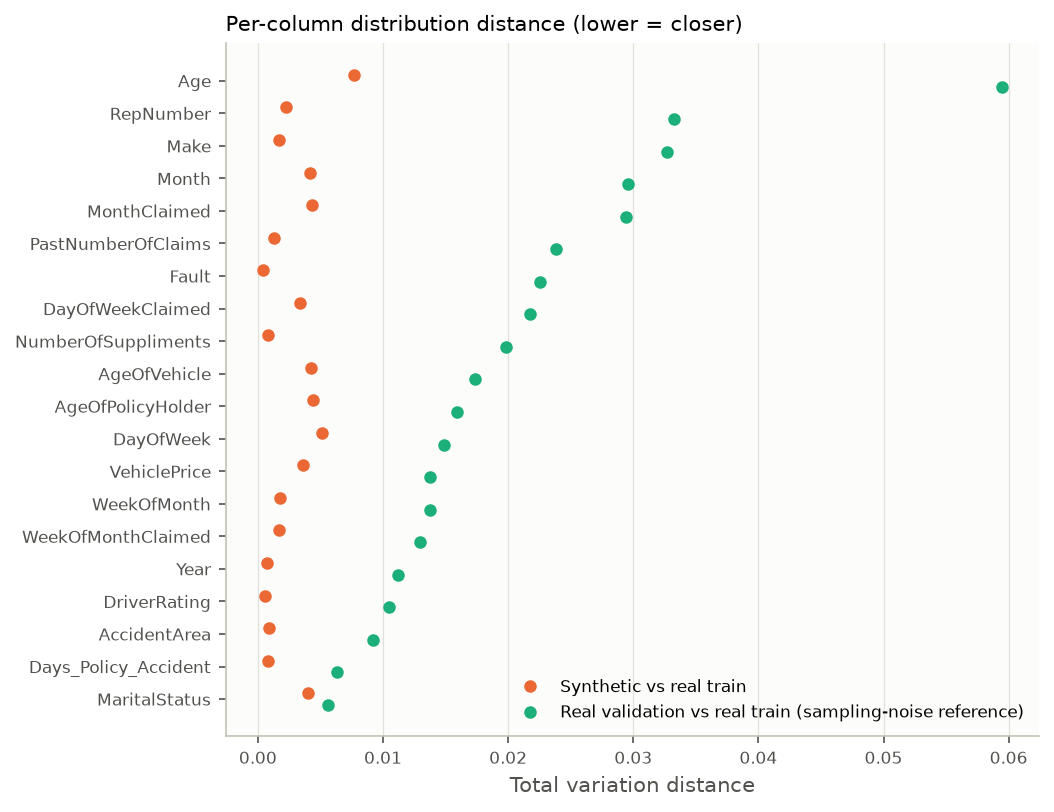

In [6]:
if RUN_SECTIONS["synthetic_audit"]:
    cols = sa.COMPARE_COLUMNS
    fid_train = sa.tvd_and_chi2(raw["real_train"], raw["synthetic"], cols)
    fid_val = sa.tvd_and_chi2(raw["real_validation"], raw["synthetic"], cols).set_index("column")
    ref_val = sa.tvd_and_chi2(raw["real_train"], raw["real_validation"], cols).set_index("column")
    fid = fid_train.assign(tvd_syn_vs_val=fid_train.column.map(fid_val.tvd),
                           p_syn_vs_val=fid_train.column.map(fid_val.p_value),
                           tvd_train_vs_val=fid_train.column.map(ref_val.tvd))
    fid.to_csv(TAB / "01_eda_synthetic_fidelity.csv", index=False)
    print("median chi-square p-value, synthetic vs real train:", round(fid.p_value.median(), 3),
          "| share of columns with p > 0.9:", round((fid.p_value > 0.9).mean(), 2))
    print("median chi-square p-value, synthetic vs real validation:", round(fid.p_syn_vs_val.median(), 3))
    display(fid.head(12).round(4))

    top = fid.sort_values("tvd_train_vs_val", ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(7, 6))
    eda.plot_dots(ax, top.column.tolist(),
                  {"Synthetic vs real train": (top.tvd, None, None),
                   "Real validation vs real train (sampling-noise reference)": (top.tvd_train_vs_val, None, None)},
                  "Total variation distance",
                  colors={"Synthetic vs real train": eda.ORIGIN_COLORS["synthetic"],
                          "Real validation vs real train (sampling-noise reference)": eda.ORIGIN_COLORS["real_validation"]})
    ax.set_title("Per-column distribution distance (lower = closer)", loc="left", fontsize=10)
    eda.save(fig, FIG / "01_synthetic_tvd.png"); display(Image(FIG / "01_synthetic_tvd.png"))

### 2.2 Fidelity: fraud rate per category, associations, mutual information, coverage

categories with >=30 real rows: 164; correlation of fraud rates real vs synthetic: 0.891
Red flags (lift > 1.5) weakened to < 1.2 in synthetic, or protective signals lost:


,column,value,n_real,rate_real,n_syn,rate_syn,lift_real,lift_syn
30,Make,Mercury,54,0.093,1391,0.065,1.547,1.093
35,Make,VW,198,0.020,5282,0.051,0.338,0.851
40,DayOfWeekClaimed,Saturday,94,0.106,2513,0.068,1.777,1.144
116,AgeOfVehicle,2 years,58,0.034,1518,0.069,0.576,1.156


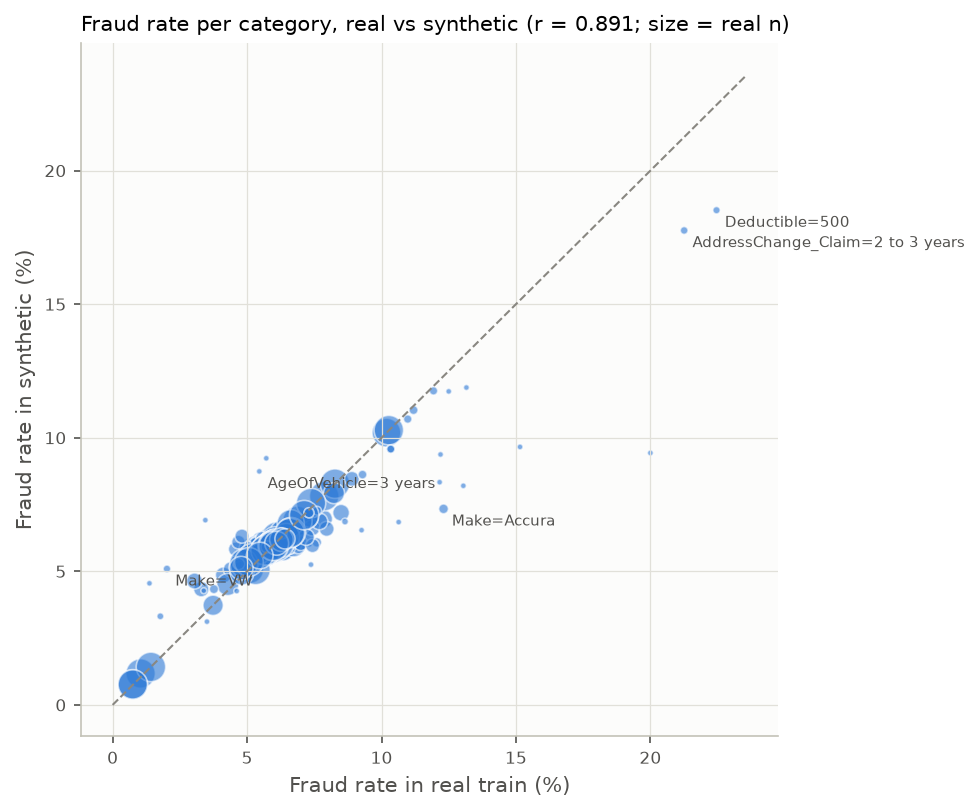

In [7]:
if RUN_SECTIONS["synthetic_audit"]:
    feat_cols = [c for c in CLAIM_FIELDS if c != "Age"] + ["age_band"]
    agree = sa.fraud_rate_agreement(rt, syn, feat_cols, min_n=30)
    agree.to_csv(TAB / "01_eda_rate_agreement.csv", index=False)
    r = np.corrcoef(agree.rate_real, agree.rate_syn)[0, 1]
    flips = agree[(agree.lift_real > 1.5) & (agree.lift_syn < 1.2) | (agree.lift_real < 0.67) & (agree.lift_syn > 0.85)]
    print(f"categories with >=30 real rows: {len(agree)}; correlation of fraud rates real vs synthetic: {r:.3f}")
    print("Red flags (lift > 1.5) weakened to < 1.2 in synthetic, or protective signals lost:")
    display(flips.round(3))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(100 * agree.rate_real, 100 * agree.rate_syn, s=np.clip(agree.n_real / 15, 8, 200),
               color=eda.ORIGIN_COLORS["real_train"], alpha=0.6, edgecolor="white", lw=0.8)
    lim = 100 * max(agree.rate_real.max(), agree.rate_syn.max()) * 1.05
    ax.plot([0, lim], [0, lim], color=eda.MUTED, lw=1, ls="--")
    for _, row in agree[(agree.n_real >= 100) & ((agree.rate_real - agree.rate_syn).abs() > 0.03)].iterrows():
        ax.annotate(f"{row.column}={row.value}", (100 * row.rate_real, 100 * row.rate_syn), fontsize=7,
                    color=eda.INK_2, xytext=(4, -8), textcoords="offset points")
    ax.set_xlabel("Fraud rate in real train (%)"); ax.set_ylabel("Fraud rate in synthetic (%)")
    ax.set_title(f"Fraud rate per category, real vs synthetic (r = {r:.3f}; size = real n)", loc="left", fontsize=10)
    ax.grid(color=eda.GRID, lw=0.6); eda.style_axes(ax)
    eda.save(fig, FIG / "01_synthetic_rate_agreement.png"); display(Image(FIG / "01_synthetic_rate_agreement.png"))

Cramér's V difference (synthetic - real): mean |d| = 0.0186, max |d| = 0.2095


,a,b,v_real,v_syn,diff
289,PolicyType,Deductible,0.219,0.010,-0.210
335,VehiclePrice,AgentType,0.099,0.028,-0.071
222,Sex,PolicyType,0.099,0.035,-0.065
97,Make,PolicyType,0.183,0.123,-0.060
186,MonthClaimed,PoliceReportFiled,0.065,0.005,-0.060
26,Month,NumberOfCars,0.065,0.006,-0.059
90,Make,AccidentArea,0.071,0.012,-0.059
400,Days_Policy_Accident,NumberOfCars,0.061,0.003,-0.058
240,Sex,BasePolicy,0.074,0.016,-0.058
70,DayOfWeek,VehicleCategory,0.058,0.006,-0.052


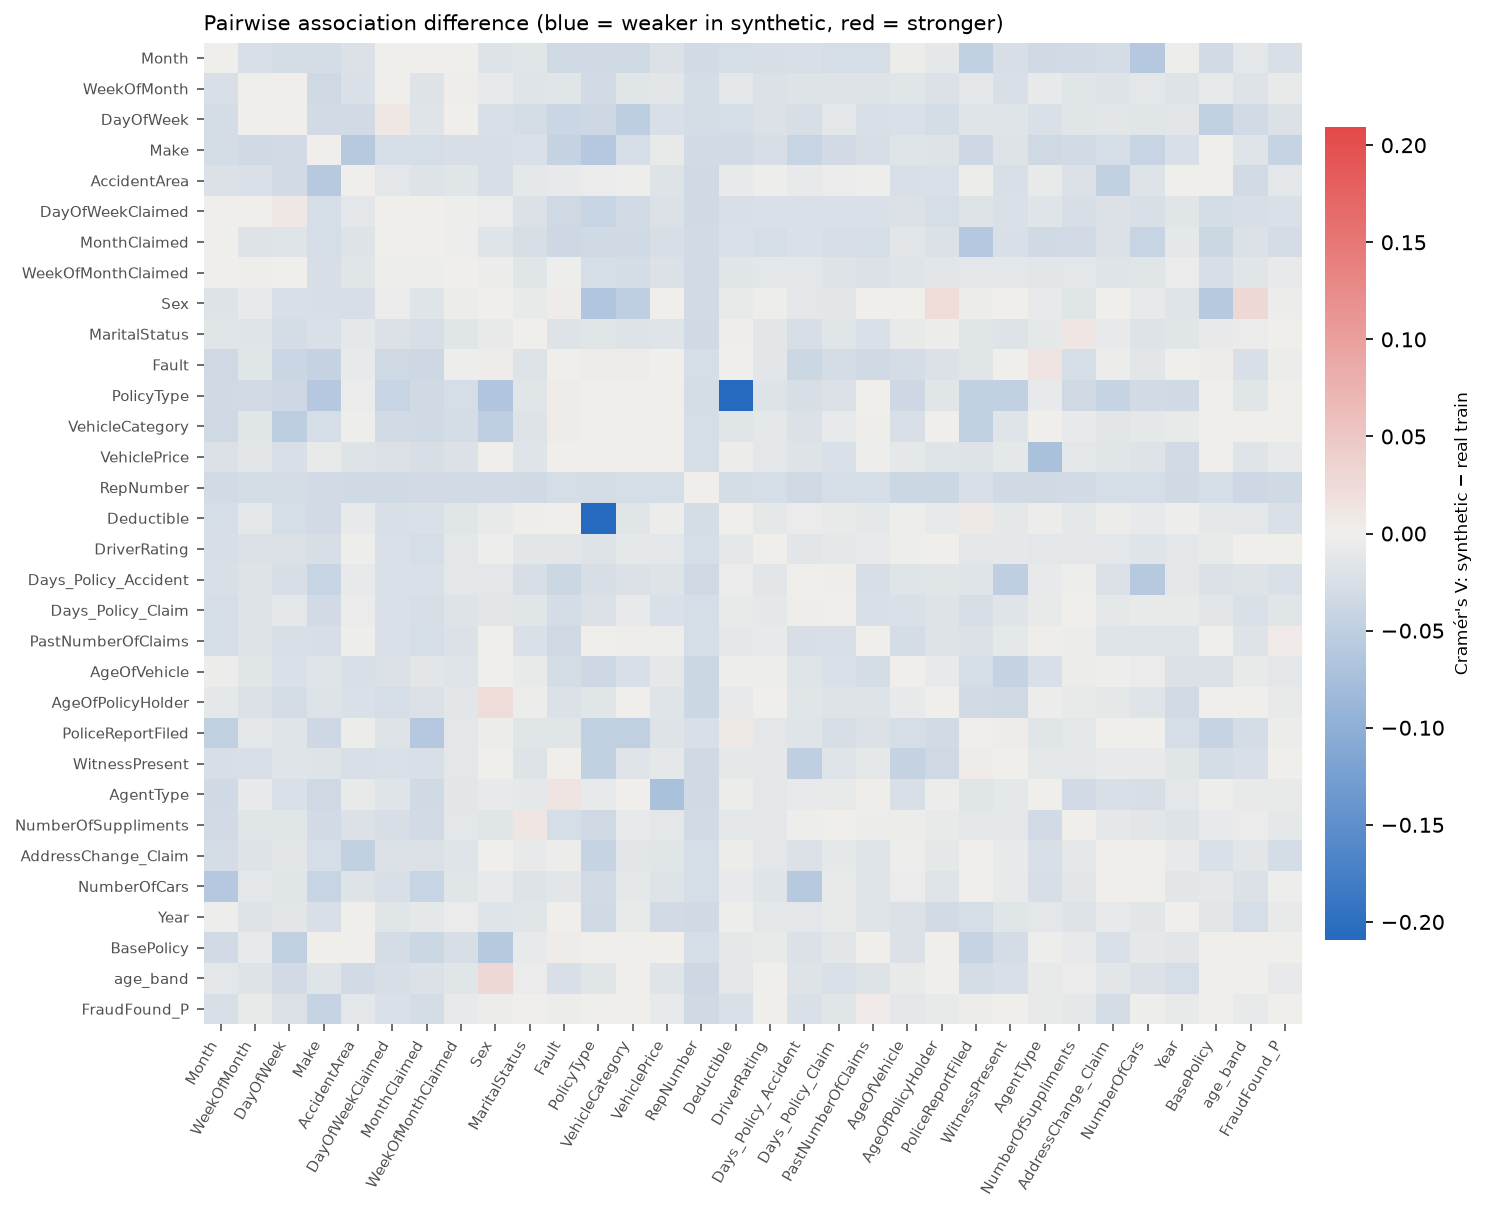

In [8]:
if RUN_SECTIONS["synthetic_audit"]:
    assoc_cols = [c for c in CLAIM_FIELDS if c not in ("Age",)] + ["age_band", TARGET]
    m_real, m_syn, m_diff = sa.cramers_difference(rt, syn, assoc_cols)
    m_diff.to_csv(TAB / "01_eda_cramers_v_difference.csv")
    iu = np.triu_indices(len(assoc_cols), 1)
    d = m_diff.values[iu]
    print(f"Cramér's V difference (synthetic - real): mean |d| = {np.abs(d).mean():.4f}, max |d| = {np.abs(d).max():.4f}")
    pairs = pd.DataFrame({"a": np.array(assoc_cols)[iu[0]], "b": np.array(assoc_cols)[iu[1]],
                          "v_real": m_real.values[iu], "v_syn": m_syn.values[iu], "diff": d})
    display(pairs.reindex(pairs["diff"].abs().sort_values(ascending=False).index).head(10).round(3))

    from matplotlib.colors import TwoSlopeNorm
    lim = max(0.05, float(np.abs(d).max()))
    fig, ax = plt.subplots(figsize=(10, 8.5))
    im = eda.plot_heatmap(ax, m_diff, eda.DIVERGING, norm=TwoSlopeNorm(0, -lim, lim))
    cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02); cb.set_label("Cramér's V: synthetic − real train", fontsize=8)
    cb.outline.set_visible(False)
    ax.set_title("Pairwise association difference (blue = weaker in synthetic, red = stronger)", loc="left", fontsize=10)
    eda.save(fig, FIG / "01_synthetic_cramers_diff.png"); display(Image(FIG / "01_synthetic_cramers_diff.png"))

In [9]:
if RUN_SECTIONS["synthetic_audit"]:
    mi = sa.mutual_information(raw["real_train"], raw["synthetic"], CLAIM_FIELDS)
    mi.to_csv(TAB / "01_eda_mutual_information.csv", index=False)
    display(mi.head(12).round(4))
    cov = sa.category_coverage(raw["real_train"], raw["synthetic"], CLAIM_FIELDS)
    cov_summary = {k: v for k, v in cov.items() if k != "novel_pair_row_mask"}
    print(cov_summary)

,column,mi_real,mi_syn,rank_real,rank_syn
0,PolicyType,0.0167,0.0168,1,1
1,BasePolicy,0.0166,0.0165,2,2
2,VehicleCategory,0.0121,0.0122,3,3
3,Fault,0.0110,0.0103,4,4
4,AddressChange_Claim,0.0030,0.0018,5,5
5,Deductible,0.0025,0.0017,6,6
6,MonthClaimed,0.0013,0.0004,7,12
7,Month,0.0013,0.0006,8,10
8,VehiclePrice,0.0013,0.0010,9,8
9,Age,0.0012,0.0006,10,11


{'real_values_absent_in_synthetic': [], 'synthetic_values_absent_in_real': [], 'real_pair_combinations': 21187, 'real_pair_combinations_absent_in_synthetic': 18, 'synthetic_rows_with_pair_unseen_in_real_pct': np.float64(6.633656861694219)}


### 2.3 Adversarial validation (real vs synthetic, without `PolicyNumber`)

ROC-AUC real vs synthetic: 0.511 ± 0.007 (5-fold); P(synthetic) > 0.9 for 0 synthetic rows


after dropping top features: [{'dropped': 'Age', 'auc_mean': 0.5063697010343684}, {'dropped': 'RepNumber', 'auc_mean': 0.5162026289957454}]


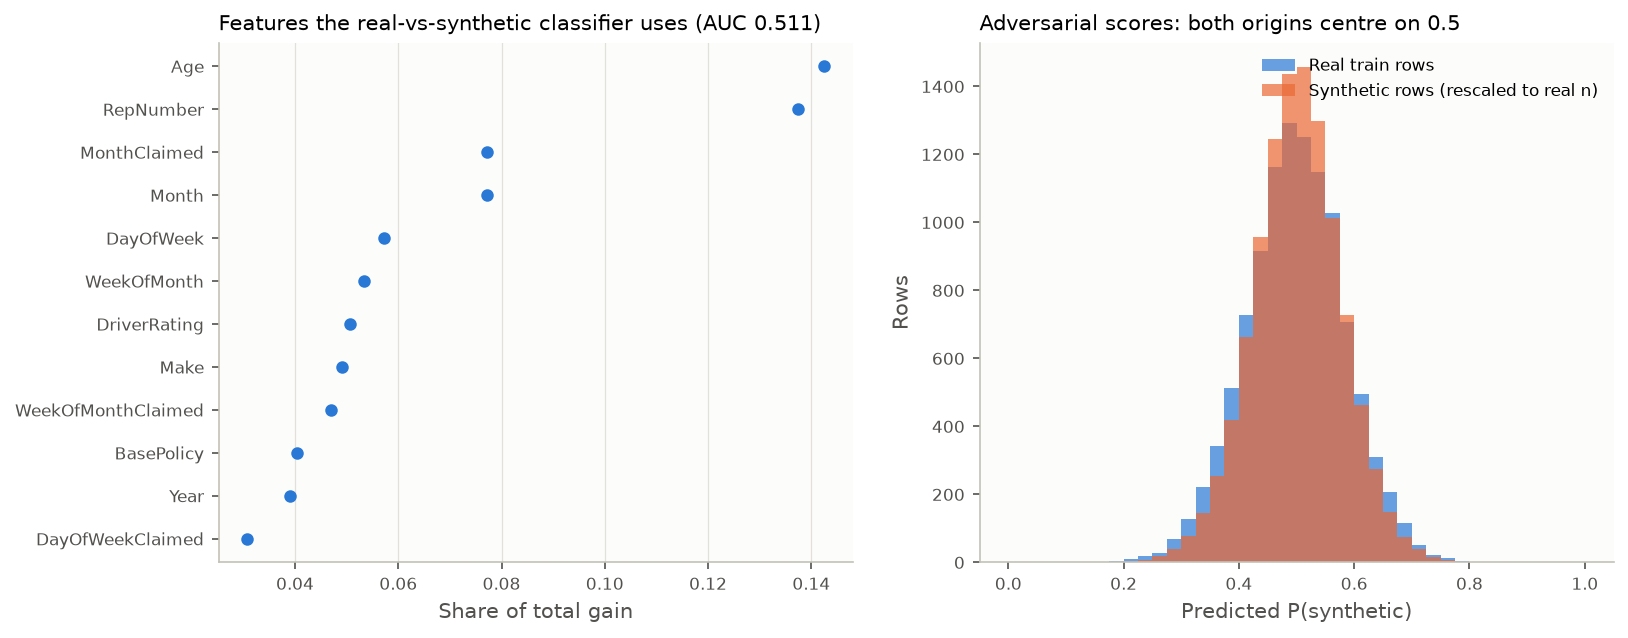

In [10]:
if RUN_SECTIONS["synthetic_audit"]:
    adv = sa.adversarial_validation(raw["real_train"], raw["synthetic"])
    print(f"ROC-AUC real vs synthetic: {adv['auc_mean']:.3f} ± {adv['auc_std']:.3f} (5-fold); "
          f"P(synthetic) > 0.9 for {(adv['p_synthetic'] > 0.9).sum()} synthetic rows")
    adv["importance"].to_frame().to_csv(TAB / "01_eda_adversarial_importance.csv")
    drop = sa.adversarial_drop_top(raw["real_train"], raw["synthetic"], adv["importance"].index.tolist(), k=2)
    print("after dropping top features:", drop)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    imp = adv["importance"].head(12)
    eda.plot_dots(axes[0], imp.index.tolist(), {"gain share": (imp.values, None, None)}, "Share of total gain")
    axes[0].set_title(f"Features the real-vs-synthetic classifier uses (AUC {adv['auc_mean']:.3f})", loc="left", fontsize=10)
    bins = np.linspace(0, 1, 41)
    axes[1].hist(adv["p_real_oof"], bins=bins, color=eda.ORIGIN_COLORS["real_train"], alpha=0.7, label="Real train rows")
    axes[1].hist(adv["p_synthetic"], bins=bins, color=eda.ORIGIN_COLORS["synthetic"], alpha=0.7, density=False,
                 weights=np.full(len(adv["p_synthetic"]), len(adv["p_real_oof"]) / len(adv["p_synthetic"])),
                 label="Synthetic rows (rescaled to real n)")
    axes[1].set_xlabel("Predicted P(synthetic)"); axes[1].set_ylabel("Rows"); axes[1].legend(frameon=False, fontsize=8)
    axes[1].set_title("Adversarial scores: both origins centre on 0.5", loc="left", fontsize=10)
    eda.style_axes(axes[1])
    eda.save(fig, FIG / "01_synthetic_adversarial.png"); display(Image(FIG / "01_synthetic_adversarial.png"))

### 2.4 Utility: TRTR vs TSTR vs mixes, all scored on real validation

The same LightGBM model is used throughout: class-weighted, with early stopping on a 10% slice
of the *training* data. Scores are averaged over seeds. A class-weighted logistic regression
checks that the result holds for a second model family. The CIs are stratified bootstrap
intervals over the 2,313 validation claims (139 frauds).

filtered synthetic keeps 270,010 of 289,207 rows


,config,model,train_rows,pr_auc,pr_lo,pr_hi,pr_auc_seed_sd,roc_auc,roc_lo,roc_hi
0,TRTR: real only,lgbm,10793,0.2116,0.1708,0.2779,0.0109,0.8288,0.8039,0.8531
1,"TSTR: synthetic, same size as real",lgbm,10793,0.1827,0.1504,0.2351,0.0112,0.8054,0.7755,0.8336
2,TSTR: all synthetic,lgbm,289207,0.2599,0.2128,0.3314,0.0056,0.8660,0.8448,0.8878
3,real + all synthetic (w=1.0),lgbm,300000,0.2583,0.2138,0.3274,0.0057,0.8656,0.8439,0.8872
4,real + all synthetic (w=0.3),lgbm,300000,0.2662,0.2182,0.3413,0.0104,0.8678,0.8465,0.8893
5,real + all synthetic (w=0.1),lgbm,300000,0.2648,0.2187,0.3408,0.0039,0.8653,0.8442,0.8872
6,real + filtered synthetic,lgbm,280803,0.2558,0.2114,0.3259,0.0097,0.8637,0.8420,0.8862
7,LogReg TRTR: real only,logreg,10793,0.1330,0.1178,0.1589,0.0000,0.7878,0.7619,0.8116
8,LogReg TSTR: all synthetic,logreg,289207,0.1674,0.1435,0.2084,0.0000,0.8090,0.7788,0.8373
9,LogReg real + all synthetic,logreg,300000,0.1672,0.1441,0.2090,0.0000,0.8093,0.7792,0.8373


,config,delta_pr_auc_vs_TRTR: real only,lo,hi
0,"TSTR: synthetic, same size as real",-0.0289,-0.0759,0.0075
1,TSTR: all synthetic,0.0483,-0.0007,0.1036
2,real + all synthetic (w=1.0),0.0466,0.0008,0.0985
3,real + all synthetic (w=0.3),0.0546,0.0101,0.1067
4,real + all synthetic (w=0.1),0.0532,0.0088,0.1034
5,real + filtered synthetic,0.0441,0.0006,0.0940
6,LogReg TRTR: real only,-0.0786,-0.1364,-0.0414
7,LogReg TSTR: all synthetic,-0.0442,-0.1026,-0.0004
8,LogReg real + all synthetic,-0.0444,-0.1026,-0.0004


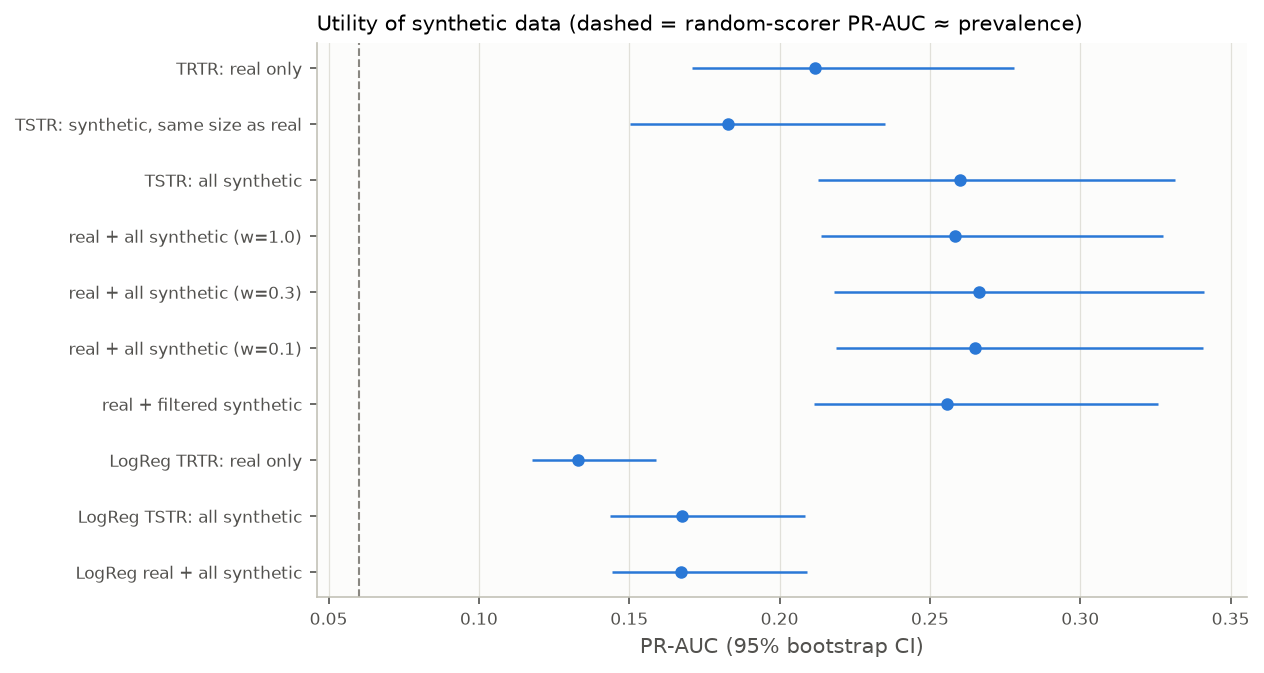

In [11]:
if RUN_SECTIONS["synthetic_audit"]:
    v10_ok = run_rules(raw["synthetic"])["V10_POLICY_DAYS_VS_LAG"].to_numpy()
    seen_pairs = ~cov["novel_pair_row_mask"]
    configs = {
        "TRTR: real only": dict(real=True),
        "TSTR: synthetic, same size as real": dict(syn_n=len(rt)),
        "TSTR: all synthetic": dict(syn_frac=1.0),
        "real + all synthetic (w=1.0)": dict(real=True, syn_frac=1.0),
        "real + all synthetic (w=0.3)": dict(real=True, syn_frac=1.0, syn_weight=0.3),
        "real + all synthetic (w=0.1)": dict(real=True, syn_frac=1.0, syn_weight=0.1),
        "real + filtered synthetic": dict(real=True, syn_frac=1.0, syn_mask=v10_ok & seen_pairs),
        "LogReg TRTR: real only": dict(real=True, model="logreg"),
        "LogReg TSTR: all synthetic": dict(syn_frac=1.0, model="logreg"),
        "LogReg real + all synthetic": dict(real=True, syn_frac=1.0, model="logreg"),
    }
    util = sa.utility_experiment(raw["real_train"], raw["synthetic"], raw["real_validation"], configs,
                                 seeds=SEEDS, n_boot=N_BOOT)
    util_tab = util["table"]
    diffs = sa.utility_differences(util, "TRTR: real only", n_boot=N_BOOT)
    util_tab.merge(diffs, on="config", how="left").to_csv(TAB / "01_eda_utility.csv", index=False)
    print(f"filtered synthetic keeps {(v10_ok & seen_pairs).sum():,} of {len(v10_ok):,} rows")
    display(util_tab.round(4)); display(diffs.round(4))

    fig, ax = plt.subplots(figsize=(8, 4.8))
    eda.plot_dots(ax, util_tab.config.tolist(),
                  {"PR-AUC on real validation": (util_tab.pr_auc, util_tab.pr_lo, util_tab.pr_hi)},
                  "PR-AUC (95% bootstrap CI)", ref=va[TARGET].mean())
    ax.set_title("Utility of synthetic data (dashed = random-scorer PR-AUC ≈ prevalence)", loc="left", fontsize=10)
    eda.save(fig, FIG / "01_synthetic_utility.png"); display(Image(FIG / "01_synthetic_utility.png"))

### 2.5 Memorisation: distance to closest record and near-duplicates

The generator is a black box. If it had copied or over-fitted real rows, synthetic rows would
sit closer to real-train rows than genuinely new real claims (real validation) do. If it had
seen validation or test rows, synthetic rows would match those more closely than a same-size
random sample of real-train rows.

Matching uses all 32 columns except `PolicyNumber`. The test rows are used only for this
row-matching integrity check, not for any metric.

,"vs real-train sample (2,313)",vs real validation,vs real test
max matching columns (of 32),,,
26,21971,22373,21473
27,4682,4939,4715
28,853,933,862
29,106,122,110
30,5,13,16
31,0,0,0
32,0,0,0


synthetic rows with >= 31/32 matching columns: {'rt_sub': 0, 'val': 0, 'test': 0}


,p1,p5,p25,median,share_exact_0
Synthetic → real train,0.0684,0.0870,0.1120,0.1284,0.0
Real validation → real train,0.0667,0.0837,0.1100,0.1272,0.0
Synthetic → real validation,0.0840,0.1062,0.1327,0.1517,0.0
Synthetic → real-train sample (same size as validation),0.0873,0.1072,0.1334,0.1511,0.0


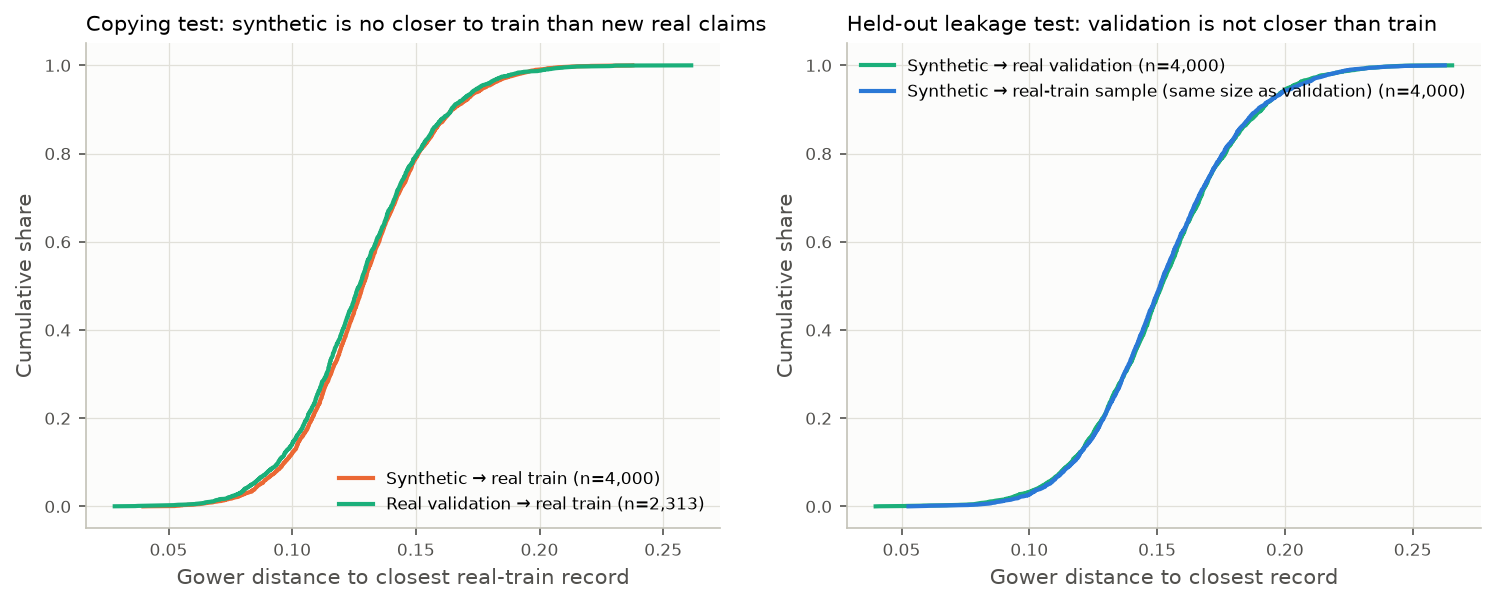

In [12]:
if RUN_SECTIONS["synthetic_audit"]:
    from src.ml.data import load_real_test
    test_raw = load_real_test()
    rng = np.random.default_rng(RANDOM_STATE)
    rt_sub = raw["real_train"].sample(len(raw["real_validation"]), random_state=RANDOM_STATE)
    codes = sa.exact_codes({"syn": raw["synthetic"], "rt": raw["real_train"], "rt_sub": rt_sub,
                            "val": raw["real_validation"], "test": test_raw})
    near = {}
    for ref in ["rt_sub", "val", "test"]:
        m = sa.max_matching_columns(codes["syn"], codes[ref])
        near[ref] = np.bincount(m, minlength=33)
    near_tab = pd.DataFrame(near, index=range(33)).loc[26:].rename(
        columns={"rt_sub": "vs real-train sample (2,313)", "val": "vs real validation", "test": "vs real test"})
    near_tab.index.name = "max matching columns (of 32)"
    near_tab.to_csv(TAB / "01_eda_near_duplicates.csv")
    display(near_tab)
    print("synthetic rows with >= 31/32 matching columns:",
          {k: int(v[31:].sum()) for k, v in near.items()})

    enc = sa.GowerEncoder().fit([raw["real_train"], raw["synthetic"], raw["real_validation"], test_raw])
    n_q = 1000 if FAST_MODE else 4000
    q_syn = raw["synthetic"].sample(n_q, random_state=RANDOM_STATE)
    E = lambda d: enc.transform(d)
    dcr = {"Synthetic → real train": sa.gower_dcr(E(q_syn), E(raw["real_train"])),
           "Real validation → real train": sa.gower_dcr(E(raw["real_validation"]), E(raw["real_train"])),
           "Synthetic → real validation": sa.gower_dcr(E(q_syn), E(raw["real_validation"])),
           "Synthetic → real-train sample (same size as validation)": sa.gower_dcr(E(q_syn), E(rt_sub))}
    dcr_tab = pd.DataFrame({k: np.quantile(v, [0.01, 0.05, 0.25, 0.5]) for k, v in dcr.items()},
                           index=["p1", "p5", "p25", "median"]).T
    dcr_tab["share_exact_0"] = [float((v == 0).mean()) for v in dcr.values()]
    dcr_tab.to_csv(TAB / "01_eda_dcr.csv")
    display(dcr_tab.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    eda.plot_ecdf(axes[0], {"Synthetic → real train": dcr["Synthetic → real train"],
                            "Real validation → real train": dcr["Real validation → real train"]},
                  "Gower distance to closest real-train record",
                  colors={"Synthetic → real train": eda.ORIGIN_COLORS["synthetic"],
                          "Real validation → real train": eda.ORIGIN_COLORS["real_validation"]})
    axes[0].set_title("Copying test: synthetic is no closer to train than new real claims", loc="left", fontsize=10)
    eda.plot_ecdf(axes[1], {"Synthetic → real validation": dcr["Synthetic → real validation"],
                            "Synthetic → real-train sample (same size as validation)": dcr["Synthetic → real-train sample (same size as validation)"]},
                  "Gower distance to closest record",
                  colors={"Synthetic → real validation": eda.ORIGIN_COLORS["real_validation"],
                          "Synthetic → real-train sample (same size as validation)": eda.ORIGIN_COLORS["real_train"]})
    axes[1].set_title("Held-out leakage test: validation is not closer than train", loc="left", fontsize=10)
    eda.save(fig, FIG / "01_synthetic_dcr.png"); display(Image(FIG / "01_synthetic_dcr.png"))

### 2.6 Verdict

See `docs/report/01_eda_report.md` §2.6. Recommendation: **train on real + all synthetic rows**,
with the synthetic sample weight (0.1 / 0.3 / 1.0) chosen by the Step B data-mix experiment.
Filtering does not help.

## 3. Fraud EDA (real train first, confirmed on synthetic)
### 3.1 Target distribution

In [13]:
if RUN_SECTIONS["fraud_eda"]:
    from src.ml.evaluate import wilson_ci
    tgt = pd.DataFrame([{"split": k, "n": len(v), "fraud": int(v[TARGET].sum()), "rate": v[TARGET].mean(),
                         "lo": wilson_ci(int(v[TARGET].sum()), len(v))[0], "hi": wilson_ci(int(v[TARGET].sum()), len(v))[1]}
                        for k, v in splits.items()])
    tgt.to_csv(TAB / "01_eda_target.csv", index=False)
    display(tgt.round(4))
    print("Naive baselines: all-legit accuracy =", round(1 - BASE, 4), "| random-scorer PR-AUC ≈", round(BASE, 4))

,split,n,fraud,rate,lo,hi
0,real_train,10793,646,0.0599,0.0555,0.0645
1,synthetic,289207,17310,0.0599,0.0590,0.0607
2,real_validation,2313,139,0.0601,0.0511,0.0705


Naive baselines: all-legit accuracy = 0.9401 | random-scorer PR-AUC ≈ 0.0599


### 3.2 Fraud rate per category, by feature group (Wilson 95% CI, n)

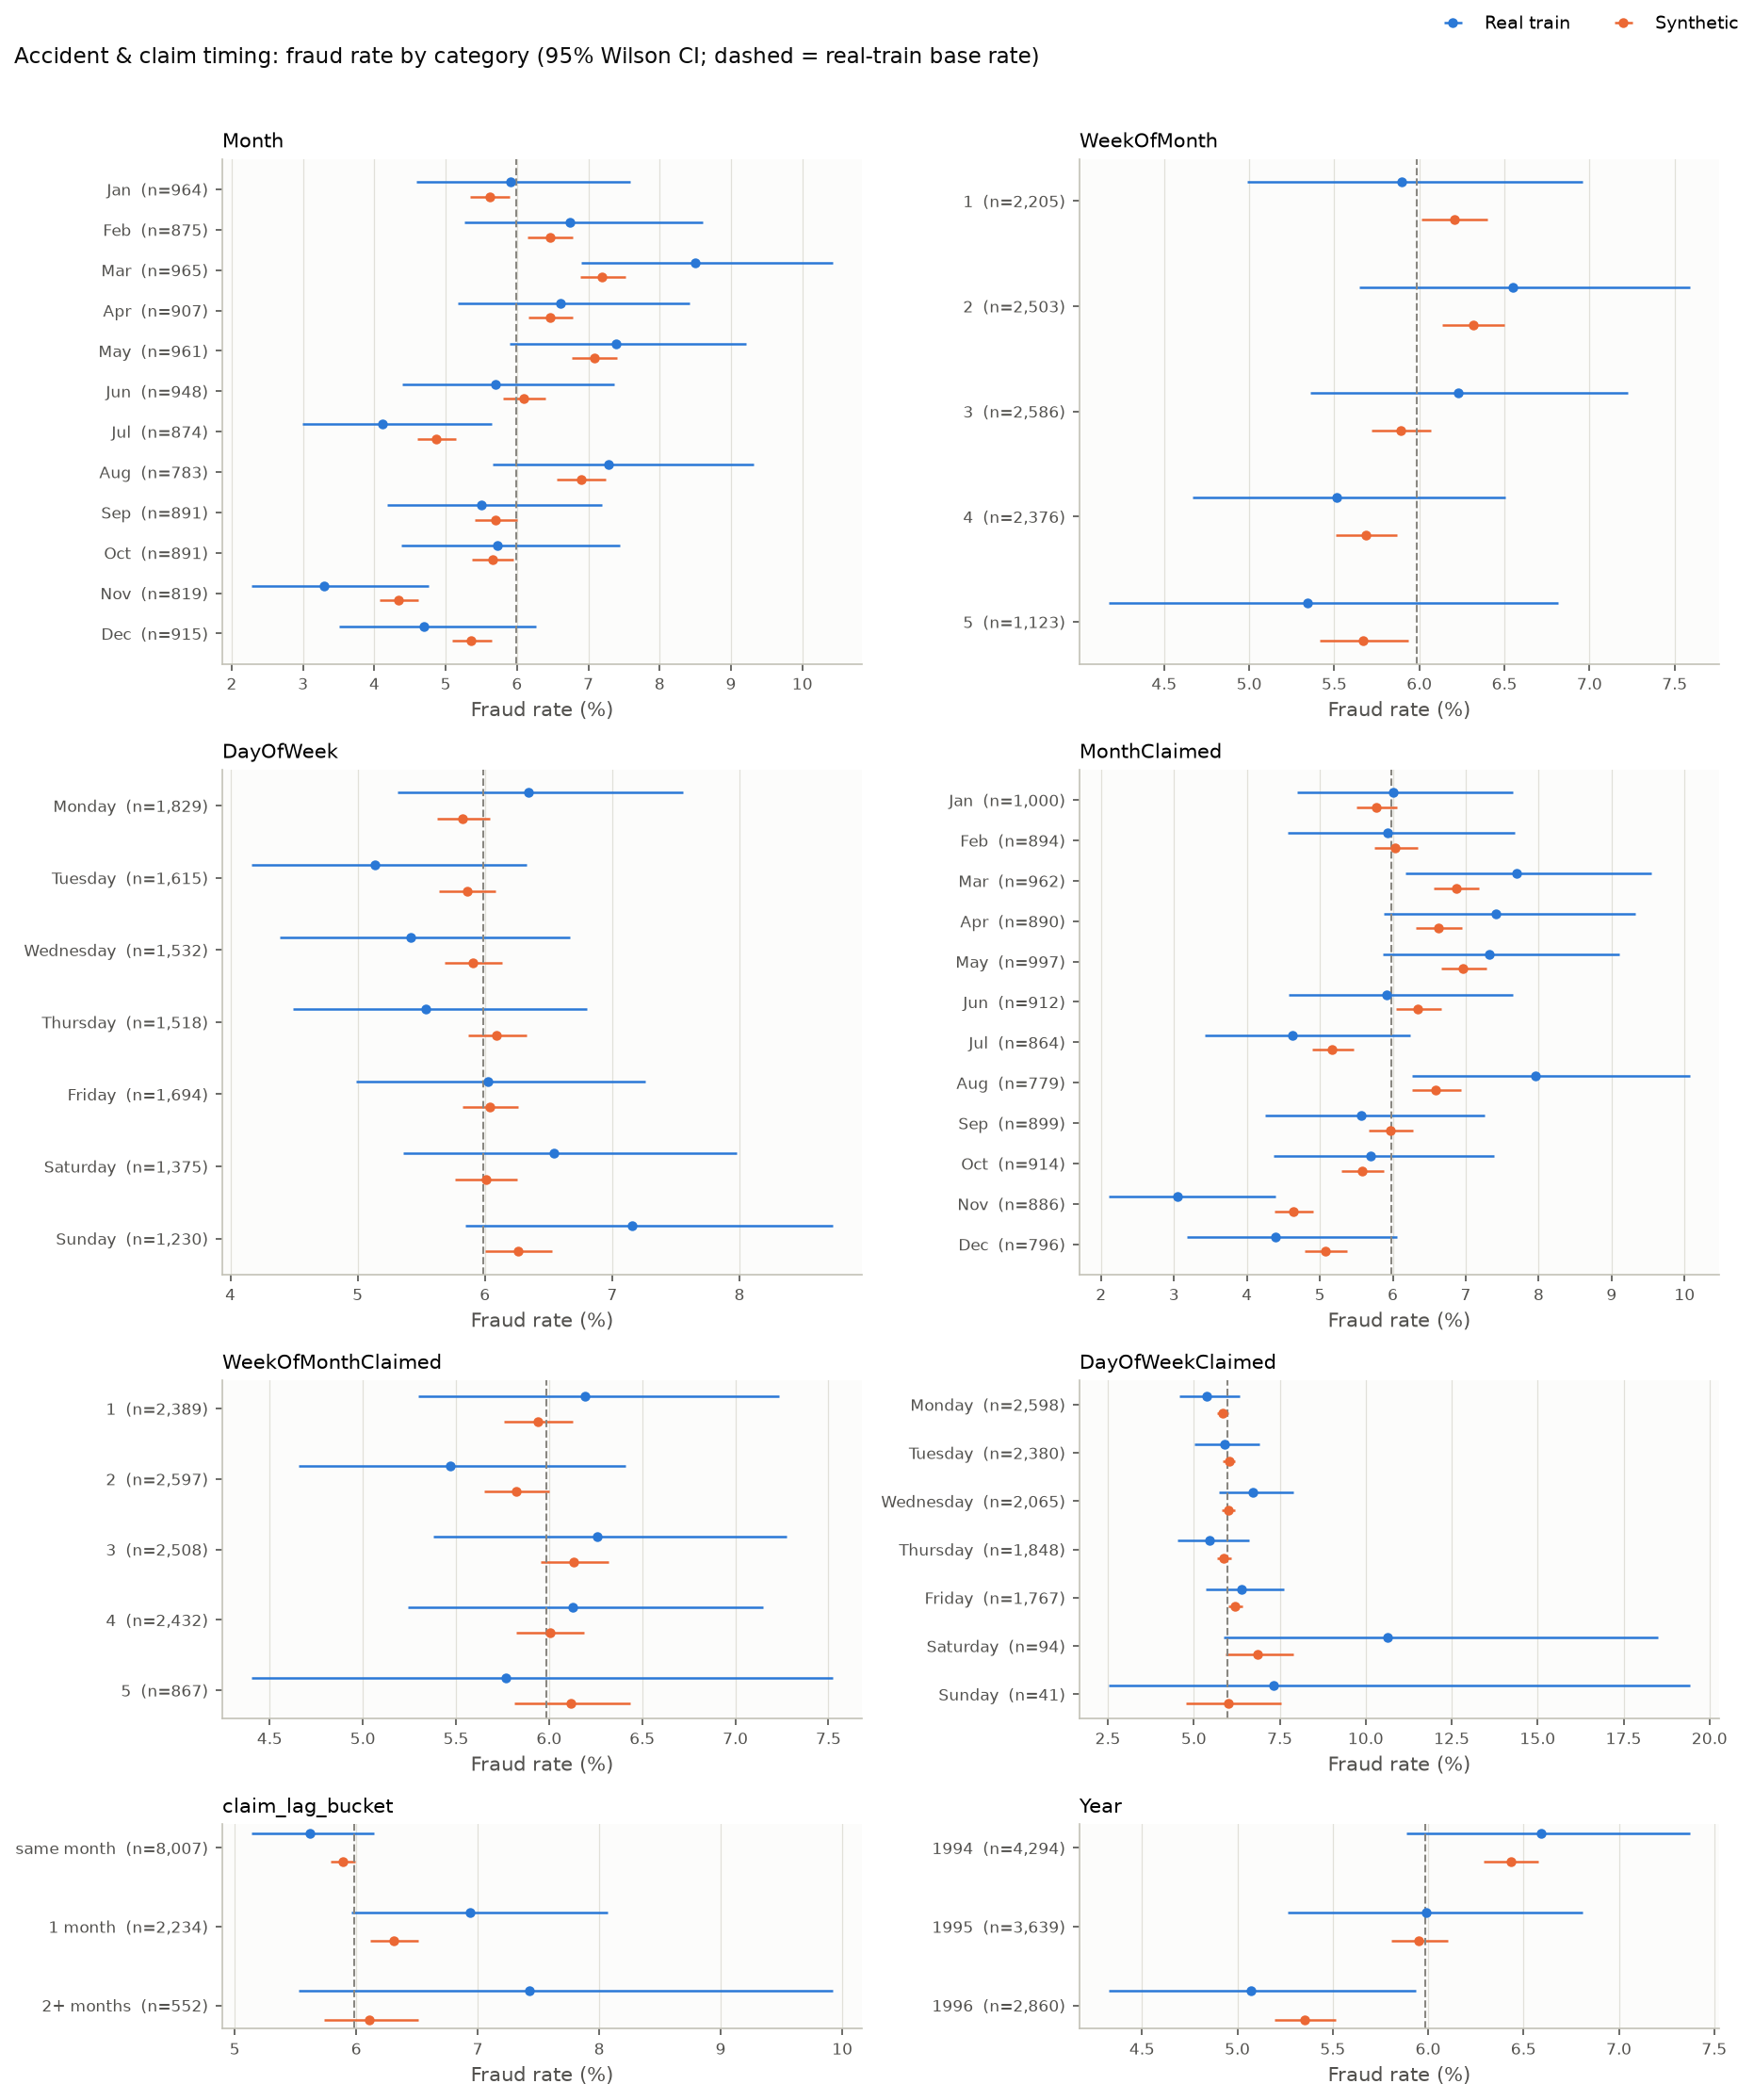

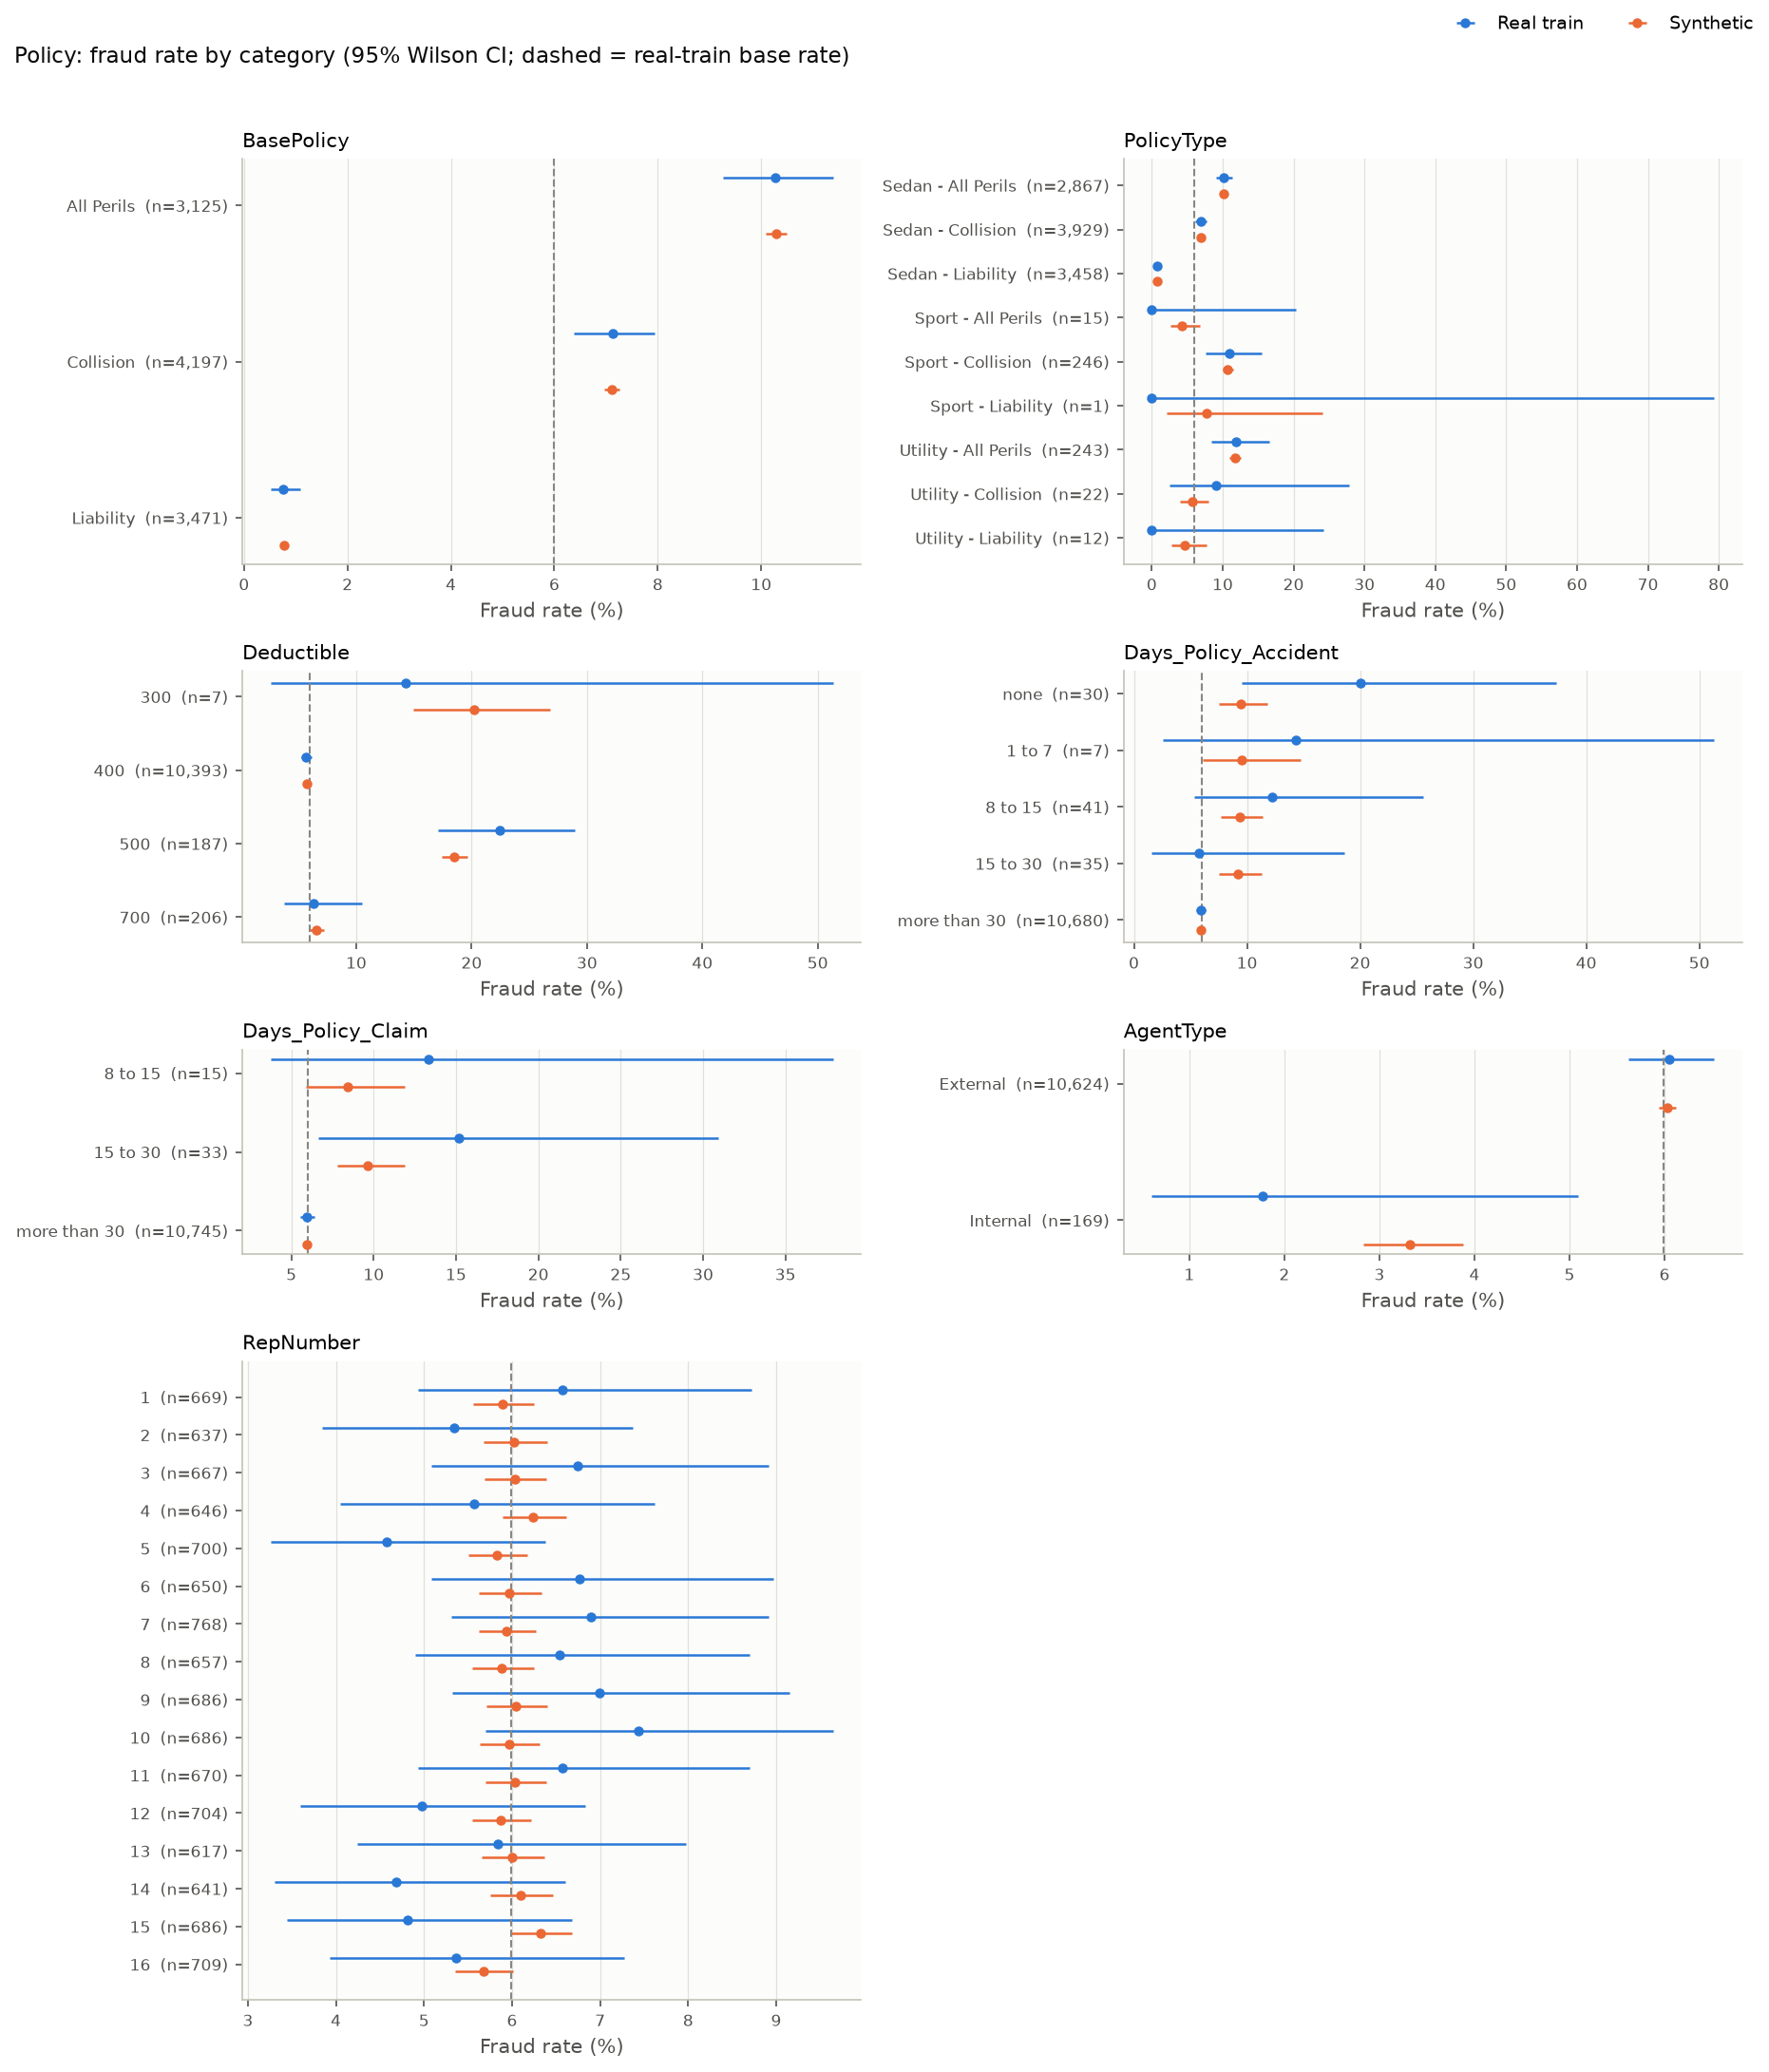

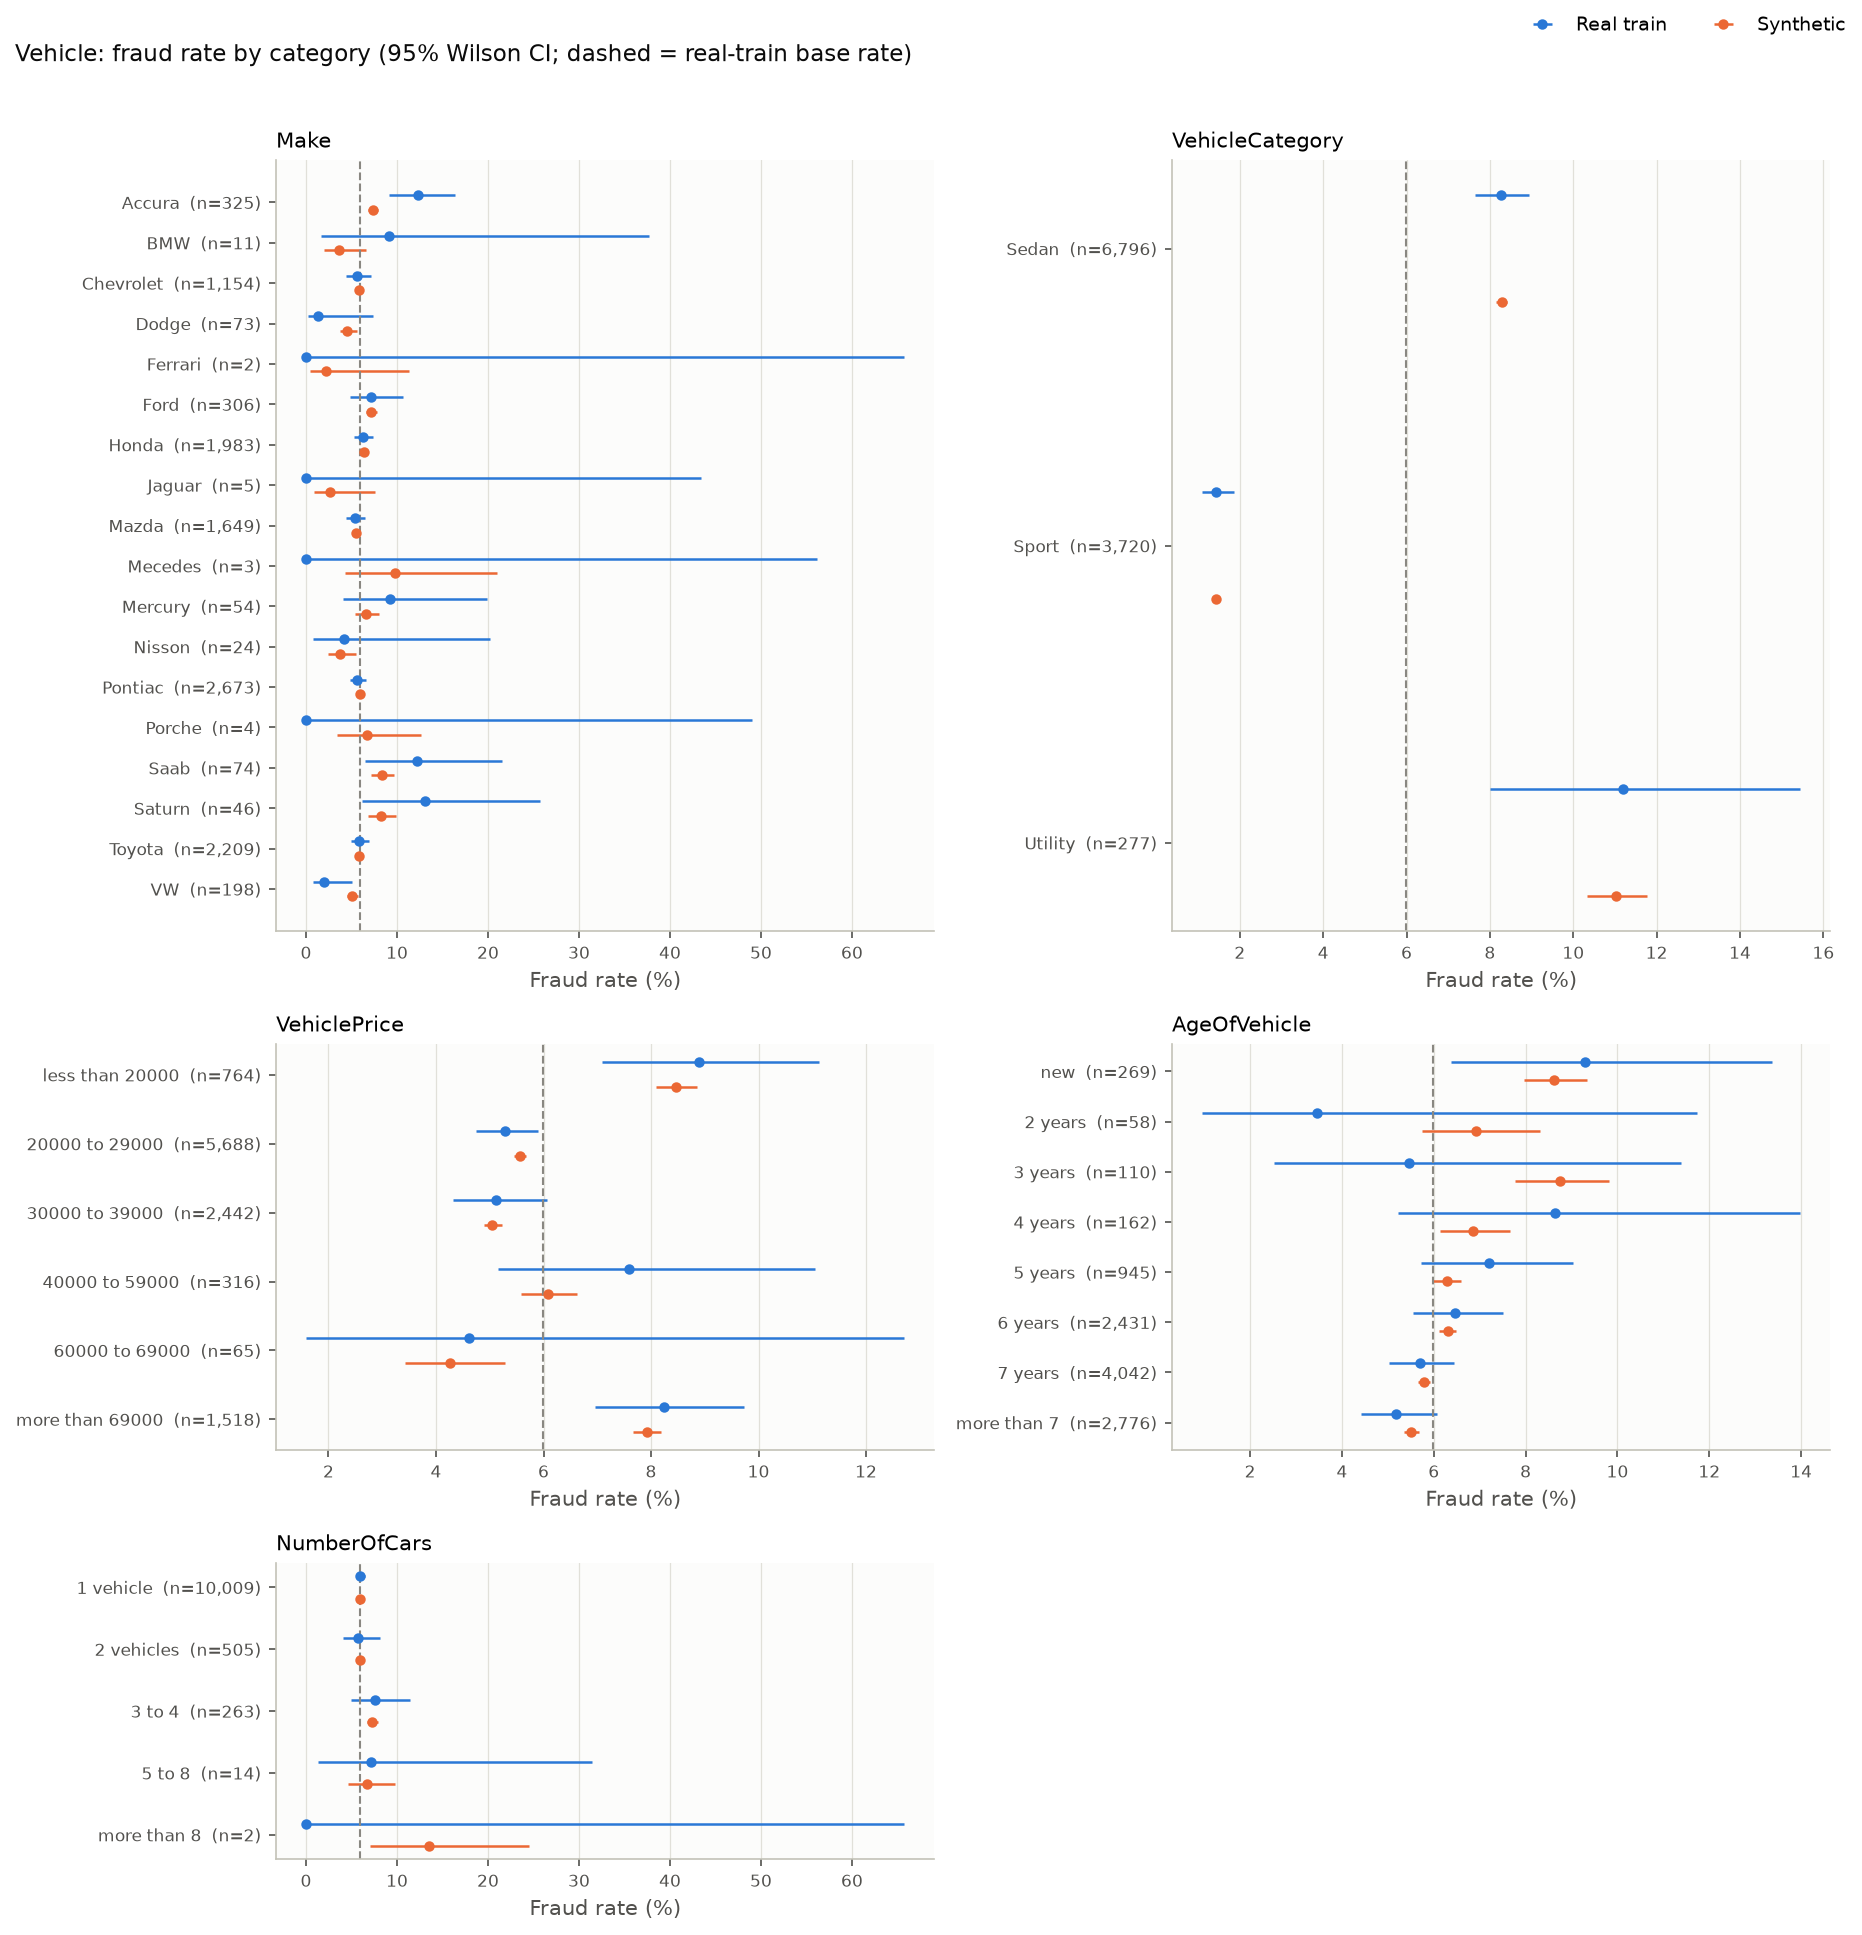

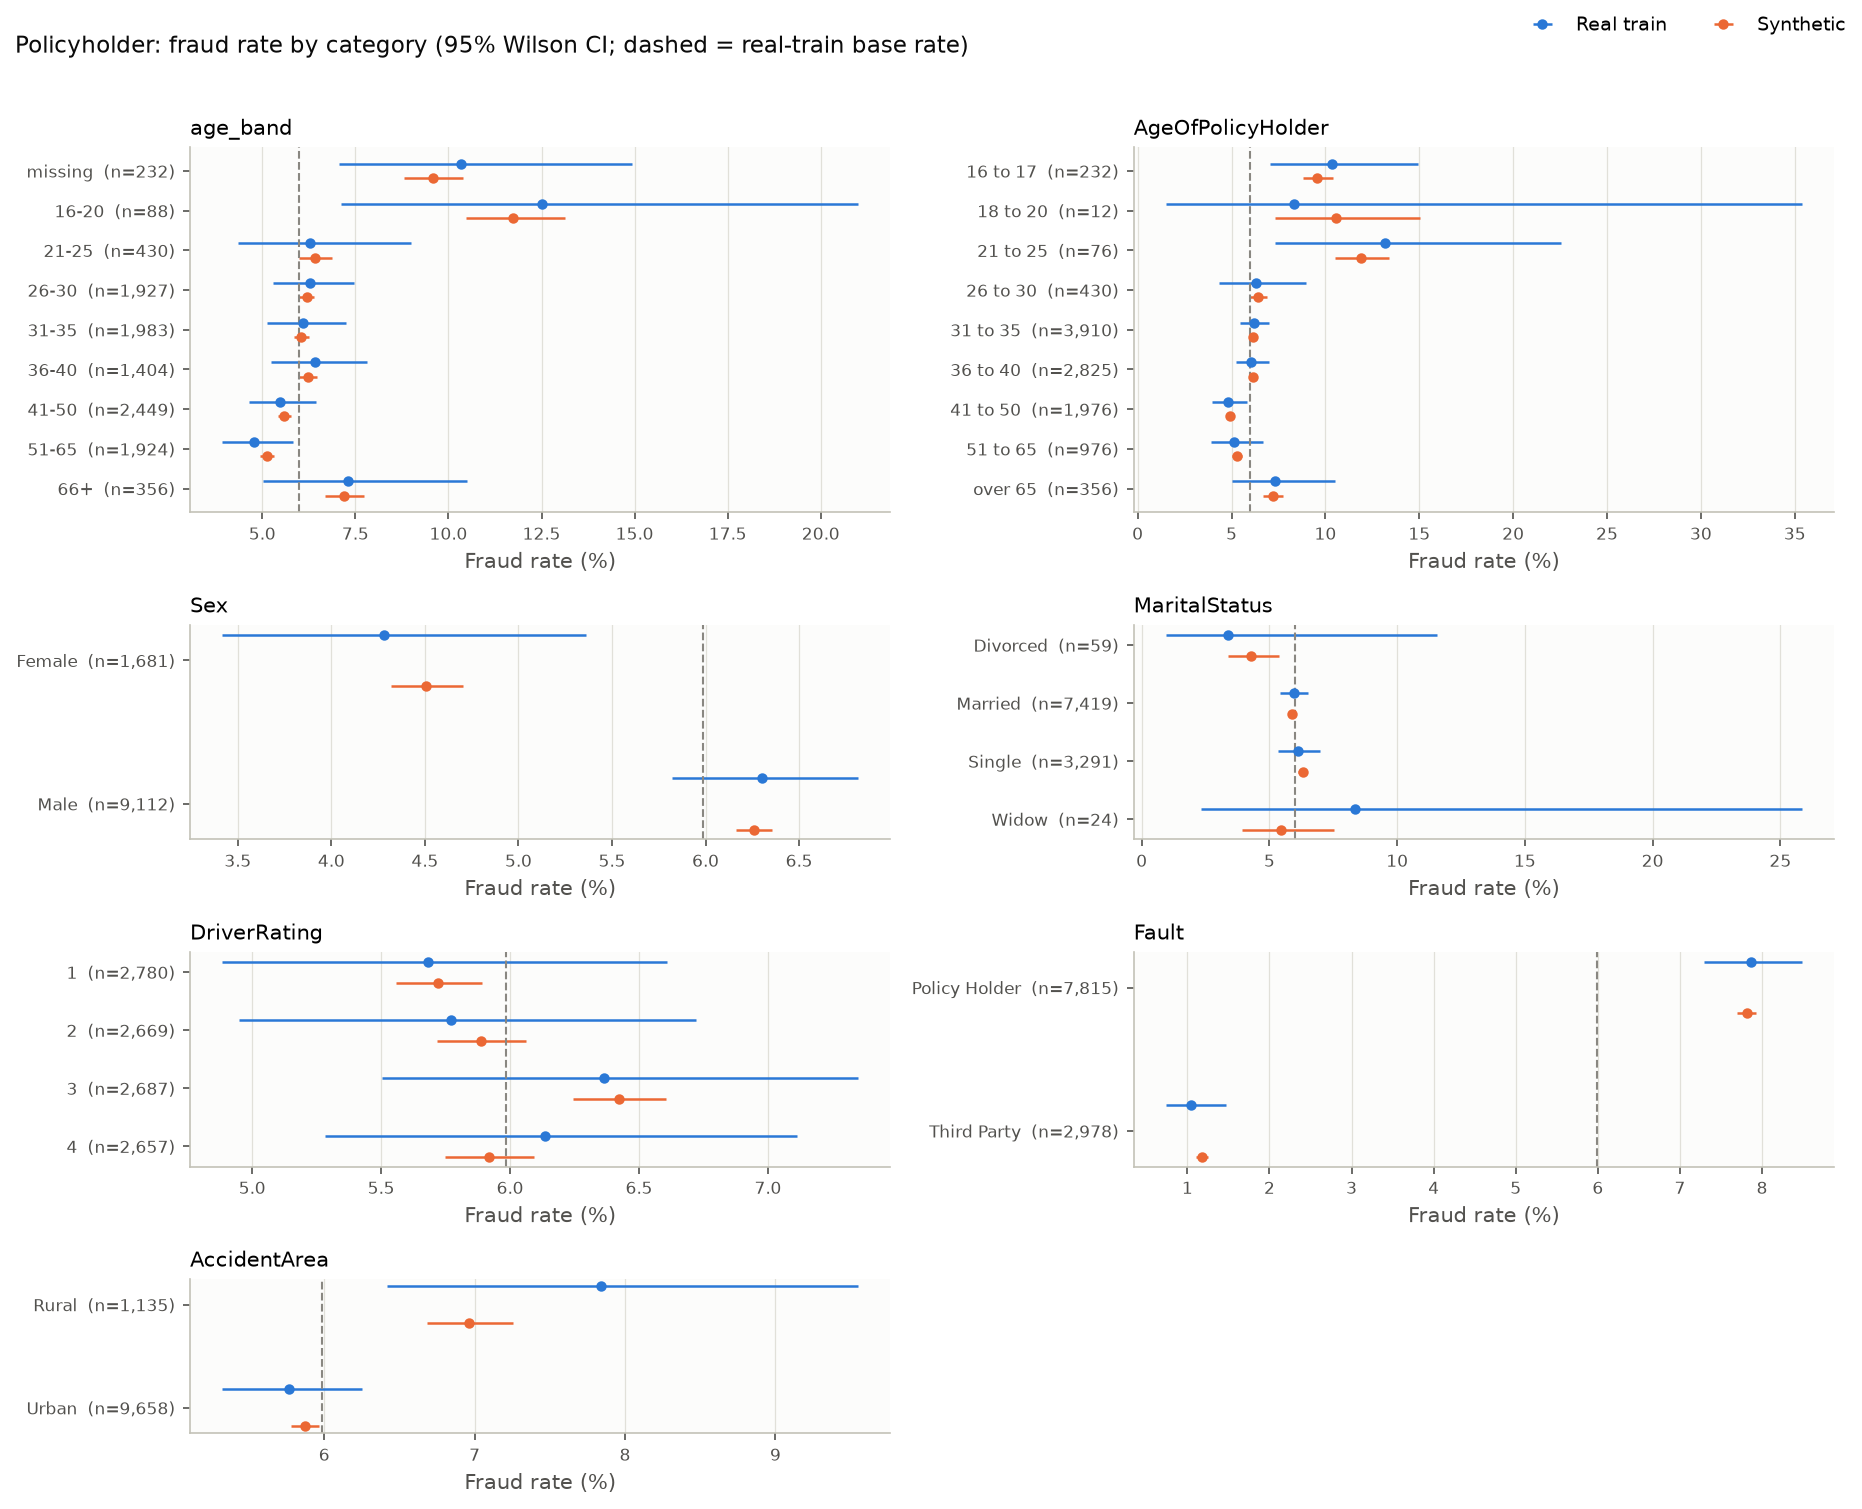

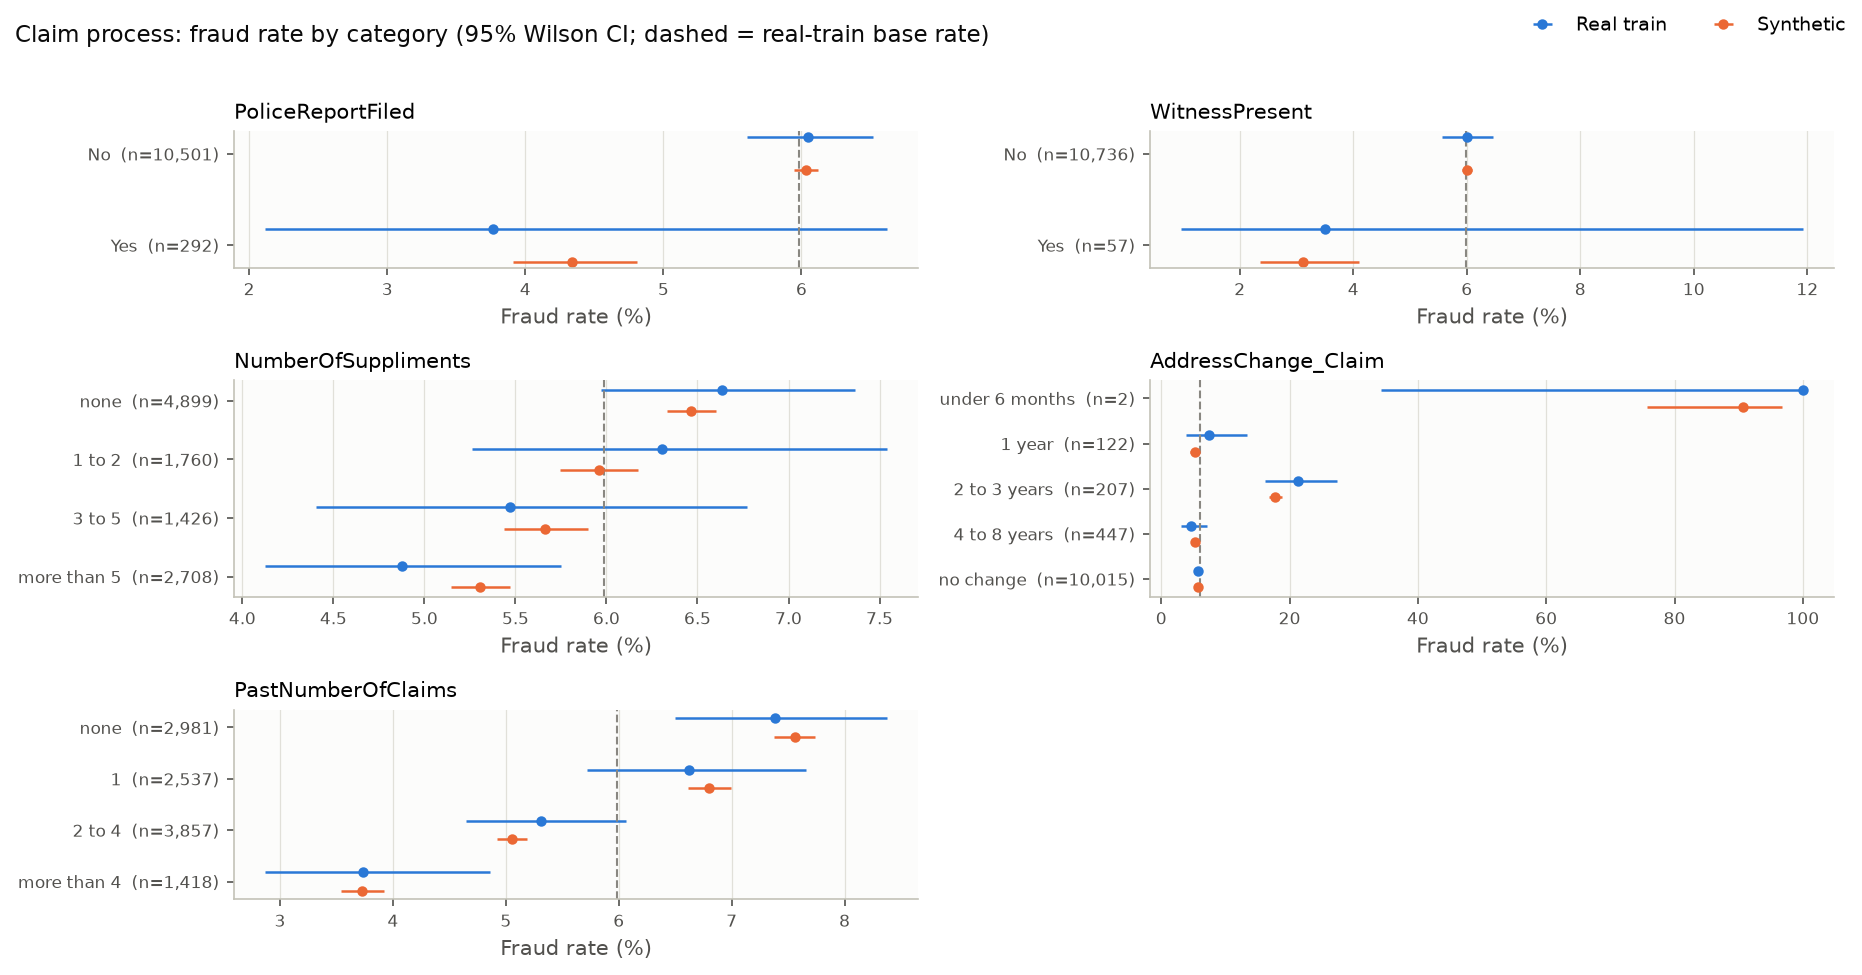

In [14]:
if RUN_SECTIONS["fraud_eda"]:
    for group, cols in eda.FEATURE_GROUPS.items():
        slug = group.lower().replace(" & ", "_").replace(" ", "_")
        p = eda.plot_rate_grid({"real_train": rt, "synthetic": syn}, cols, BASE, group, FIG / f"01_rates_{slug}.png")
        display(Image(p))
    rates = pd.concat([eda.rates_by_origin({"real_train": rt, "synthetic": syn, "real_validation": va}, c)
                       for cols in eda.FEATURE_GROUPS.values() for c in cols], ignore_index=True)
    rates.to_csv(TAB / "01_eda_rates_by_category.csv", index=False)

### 3.3 Association ranking: chi-square, Cramér's V, information value

,feature,levels,chi2,dof,p_value,cramers_v,iv,iv_strength,iv_syn,cramers_v_syn
0,PolicyType,9,291.9850,8,0.0000,0.1645,0.7847,suspicious,0.7857,0.1634
1,BasePolicy,3,280.8475,2,0.0000,0.1613,0.7753,suspicious,0.7724,0.1610
2,VehicleCategory,3,213.8569,2,0.0000,0.1408,0.5164,suspicious,0.5199,0.1407
3,Fault,2,178.6809,1,0.0000,0.1287,0.5027,suspicious,0.4619,0.1250
4,AddressChange_Claim,5,120.4716,4,0.0000,0.1057,0.0986,weak,0.0567,0.0774
5,Deductible,4,92.8481,3,0.0000,0.0928,0.0834,weak,0.0517,0.0708
6,Make,18,45.8716,17,0.0002,0.0652,0.0666,weak,0.0085,0.0223
7,MonthClaimed,12,37.1974,11,0.0001,0.0587,0.0662,weak,0.0165,0.0301
8,Month,12,37.2975,11,0.0001,0.0588,0.0639,weak,0.0230,0.0354
9,VehiclePrice,6,34.9772,5,0.0000,0.0569,0.0523,weak,0.0366,0.0474


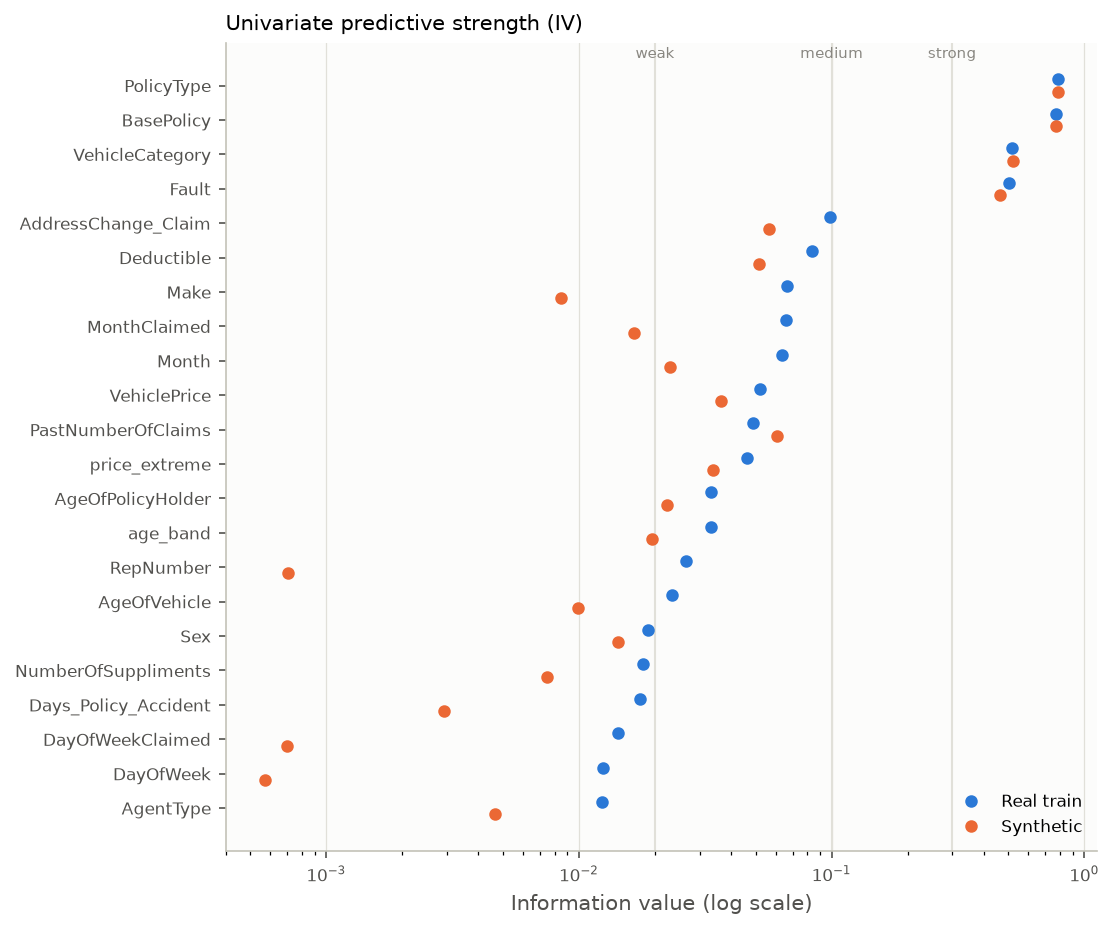

In [15]:
if RUN_SECTIONS["fraud_eda"]:
    rank_cols = [c for c in CLAIM_FIELDS if c != "Age"] + ["age_band", "claim_lag_bucket", "age_missing",
                 "accident_weekend", "claim_weekend", "early_policy_incident", "price_extreme"]
    rank = eda.association_ranking(rt, rank_cols)
    rank_syn = eda.association_ranking(syn, rank_cols).set_index("feature")
    rank["iv_syn"] = rank.feature.map(rank_syn.iv); rank["cramers_v_syn"] = rank.feature.map(rank_syn.cramers_v)
    rank.to_csv(TAB / "01_eda_association_ranking.csv", index=False)
    display(rank.round(4))

    top = rank.head(22)
    fig, ax = plt.subplots(figsize=(7.5, 7))
    eda.plot_dots(ax, top.feature.tolist(), {"Real train": (top.iv, None, None), "Synthetic": (top.iv_syn, None, None)},
                  "Information value (log scale)",
                  colors={"Real train": eda.ORIGIN_COLORS["real_train"], "Synthetic": eda.ORIGIN_COLORS["synthetic"]})
    ax.set_xscale("log")
    for x, lab in [(0.02, "weak"), (0.1, "medium"), (0.3, "strong")]:
        ax.axvline(x, color=eda.GRID, lw=1); ax.text(x, -0.8, lab, fontsize=7, color=eda.MUTED, ha="center")
    ax.set_title("Univariate predictive strength (IV)", loc="left", fontsize=10)
    eda.save(fig, FIG / "01_association_ranking.png"); display(Image(FIG / "01_association_ranking.png"))

### 3.4 Interactions and time trend

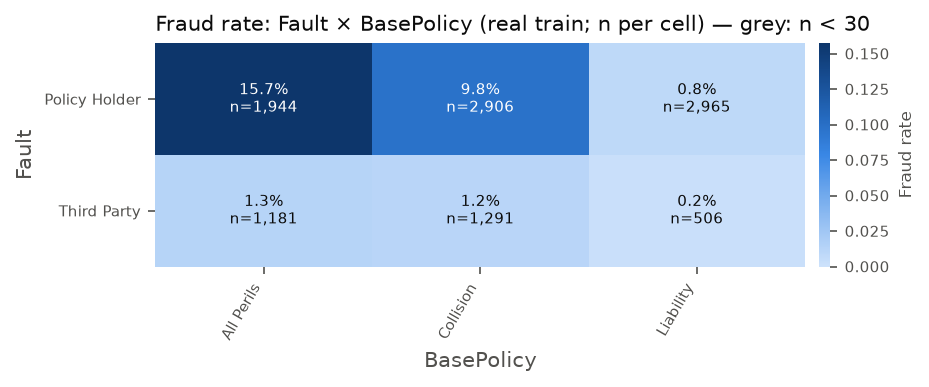

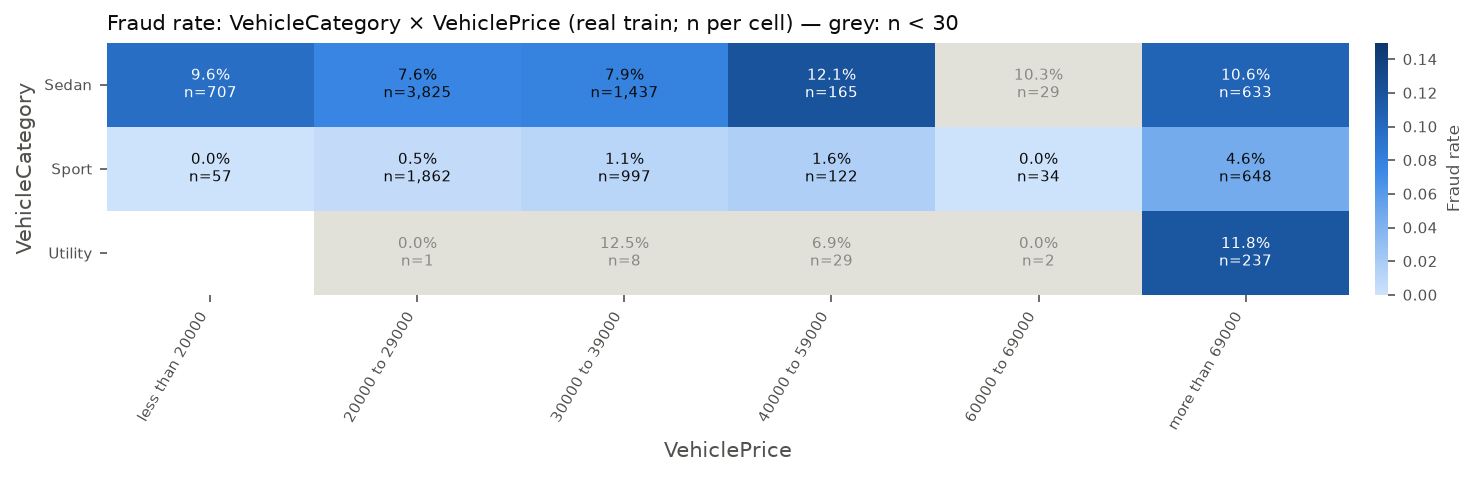

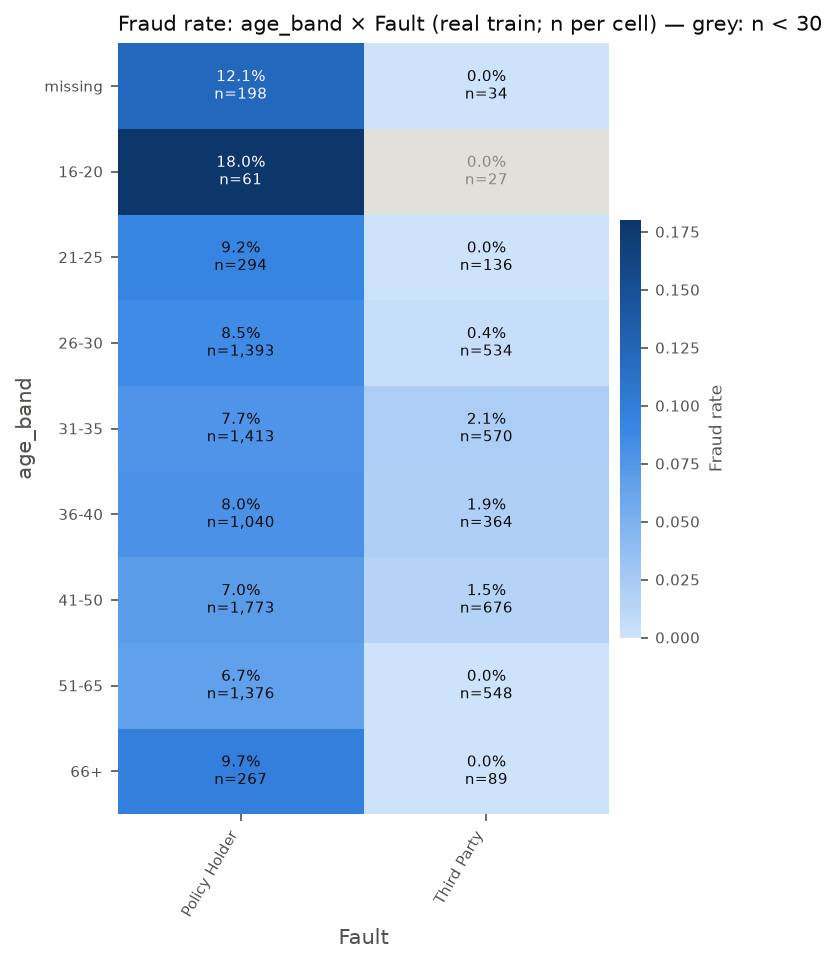

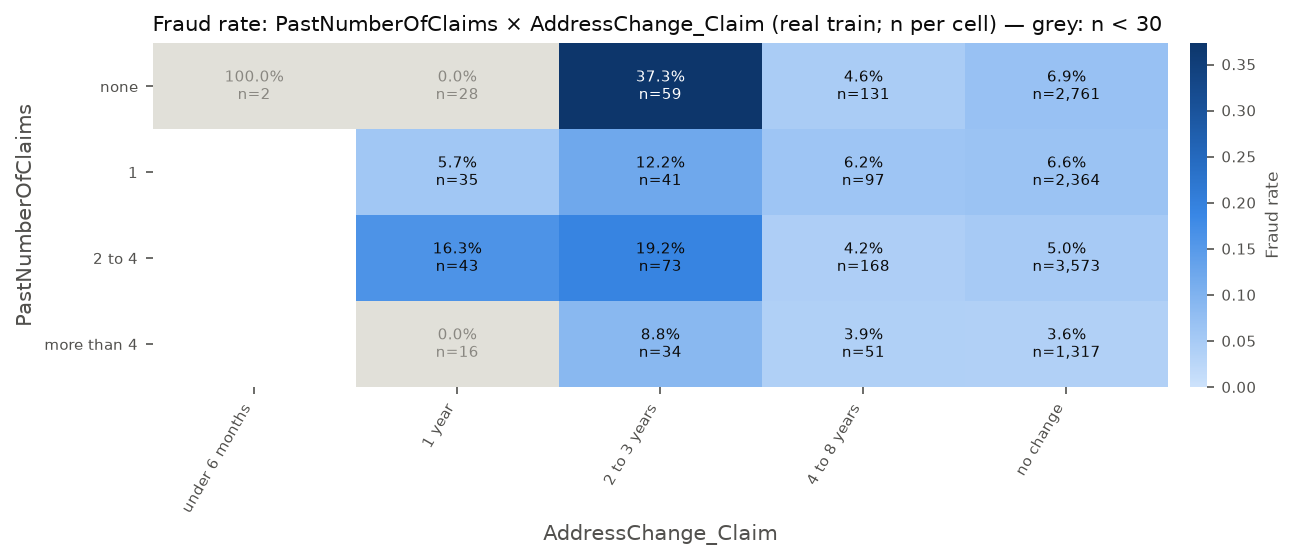

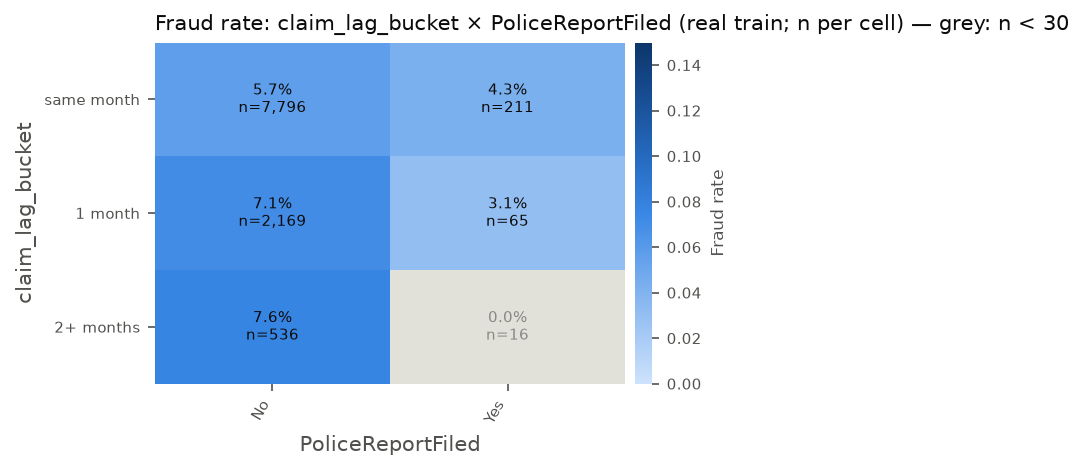

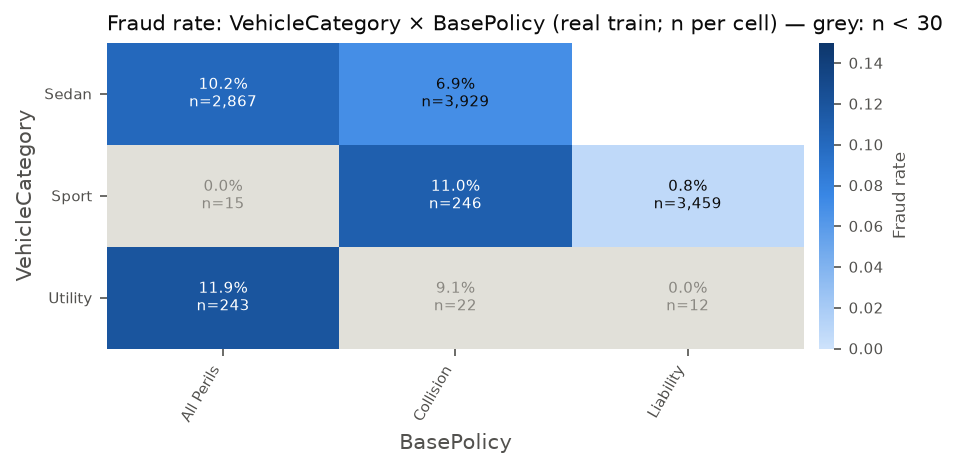

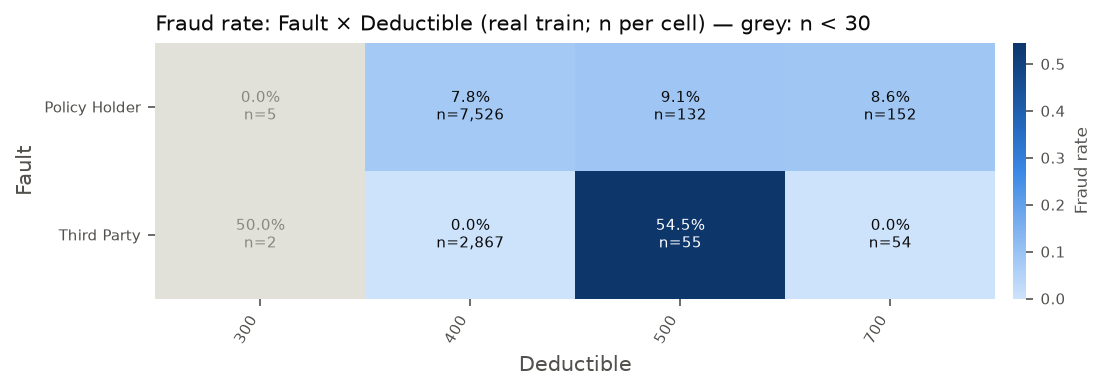

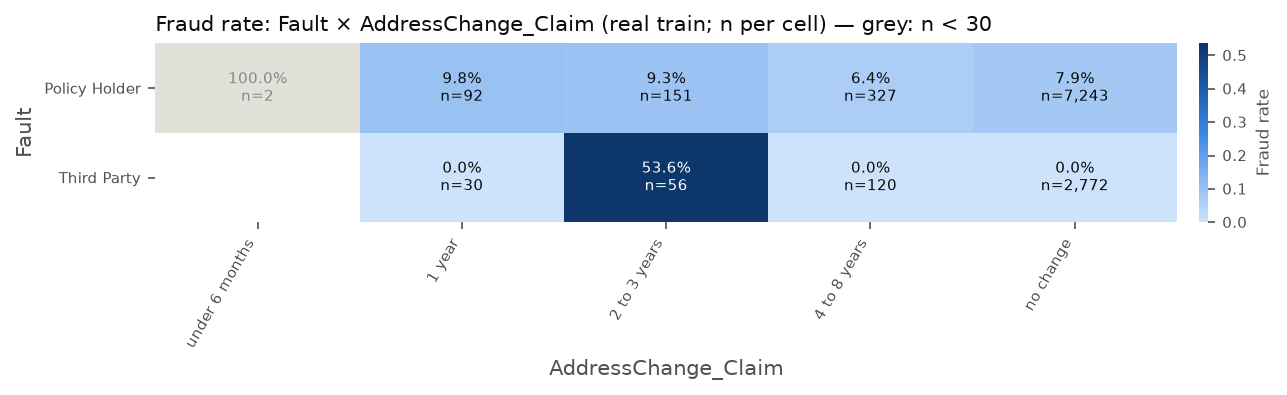

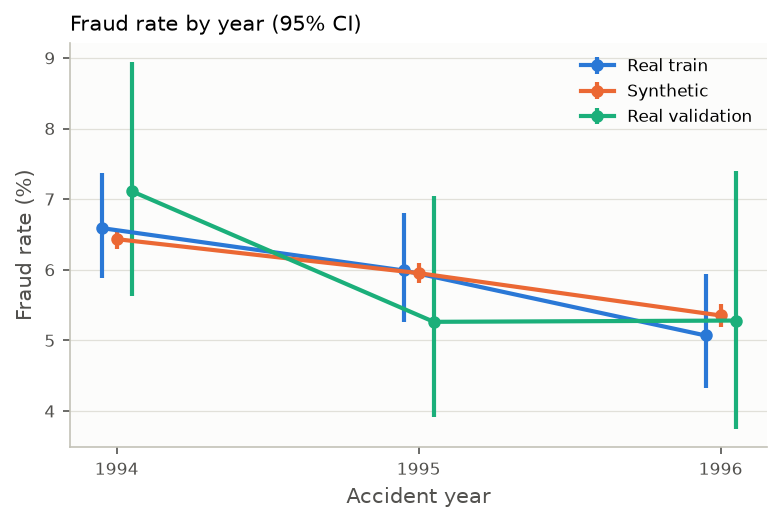

In [16]:
if RUN_SECTIONS["fraud_eda"]:
    pairs = [("Fault", "BasePolicy"), ("VehicleCategory", "VehiclePrice"), ("age_band", "Fault"),
             ("PastNumberOfClaims", "AddressChange_Claim"), ("claim_lag_bucket", "PoliceReportFiled"),
             ("VehicleCategory", "BasePolicy"), ("Fault", "Deductible"), ("Fault", "AddressChange_Claim")]
    inter = []
    for a, b in pairs:
        p = eda.plot_interaction(rt, a, b, FIG / f"01_interaction_{a}_x_{b}.png",
                                 f"Fraud rate: {a} × {b} (real train; n per cell)")
        display(Image(p))
        t = eda.interaction_table(rt, a, b).rename(columns={a: "row_value", b: "col_value"})
        ts = eda.interaction_table(syn, a, b).rename(columns={a: "row_value", b: "col_value"})
        t = t.merge(ts[["row_value", "col_value", "rate"]].rename(columns={"rate": "rate_syn"}),
                    on=["row_value", "col_value"], how="left")
        t.insert(0, "pair", f"{a} x {b}"); inter.append(t)
    pd.concat(inter).to_csv(TAB / "01_eda_interactions.csv", index=False)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    for name, df in [("real_train", rt), ("synthetic", syn), ("real_validation", va)]:
        t = eda.rate_table(df, "Year")
        ax.errorbar(t.index.astype(int) + {"real_train": -0.05, "synthetic": 0, "real_validation": 0.05}[name],
                    100 * t.rate, yerr=[100 * (t.rate - t.lo), 100 * (t.hi - t.rate)], fmt="o-", ms=5, lw=2,
                    capsize=0, color=eda.ORIGIN_COLORS[name], label=eda.ORIGIN_LABELS[name])
    ax.set_xticks([1994, 1995, 1996]); ax.set_ylabel("Fraud rate (%)"); ax.set_xlabel("Accident year")
    ax.set_title("Fraud rate by year (95% CI)", loc="left", fontsize=10); ax.legend(frameon=False, fontsize=8)
    ax.grid(axis="y", color=eda.GRID, lw=0.6); eda.style_axes(ax)
    eda.save(fig, FIG / "01_year_trend.png"); display(Image(FIG / "01_year_trend.png"))

### 3.5 Redundancy checks

In [17]:
if RUN_SECTIONS["fraud_eda"]:
    from src.validation.consistency_rules import expected_holder_bin
    red = pd.DataFrame([
        {"pair": "AgeOfPolicyHolder vs Age", "cramers_v": eda.cramers_v(rt.AgeOfPolicyHolder, rt.age_band),
         "deterministic": bool((expected_holder_bin(rt.Age) == rt.AgeOfPolicyHolder).all())},
        {"pair": "PolicyType vs VehicleCategory+BasePolicy",
         "cramers_v": eda.cramers_v(rt.PolicyType, rt.VehicleCategory + "|" + rt.BasePolicy),
         "deterministic": bool(rt.groupby(rt.VehicleCategory + "|" + rt.BasePolicy).PolicyType.nunique().max() == 1)},
        {"pair": "MonthClaimed vs Month", "cramers_v": eda.cramers_v(rt.MonthClaimed, rt.Month),
         "deterministic": False},
        {"pair": "DayOfWeekClaimed vs DayOfWeek", "cramers_v": eda.cramers_v(rt.DayOfWeekClaimed, rt.DayOfWeek),
         "deterministic": False},
        {"pair": "Days_Policy_Claim vs Days_Policy_Accident",
         "cramers_v": eda.cramers_v(rt.Days_Policy_Claim, rt.Days_Policy_Accident), "deterministic": False},
    ])
    red.to_csv(TAB / "01_eda_redundancy.csv", index=False)
    display(red.round(3))
    print("claim lag (months) distribution, real train:", rt.claim_lag_months.value_counts(normalize=True).sort_index().round(3).to_dict())

,pair,cramers_v,deterministic
0,AgeOfPolicyHolder vs Age,0.848,True
1,PolicyType vs VehicleCategory+BasePolicy,1.000,False
2,MonthClaimed vs Month,0.747,False
3,DayOfWeekClaimed vs DayOfWeek,0.146,False
4,Days_Policy_Claim vs Days_Policy_Accident,0.494,False


claim lag (months) distribution, real train: {0.0: 0.742, 1.0: 0.207, 2.0: 0.025, 3.0: 0.01, 4.0: 0.006, 5.0: 0.003, 6.0: 0.002, 7.0: 0.002, 8.0: 0.002, 9.0: 0.001, 10.0: 0.0, 11.0: 0.001}


### 3.6 Sensitive attributes (`Sex`, `MaritalStatus`, age)

We report the fraud-rate differences and run an ablation: the same LightGBM (real + synthetic,
w = 0.3) with and without each attribute, scored on real validation.

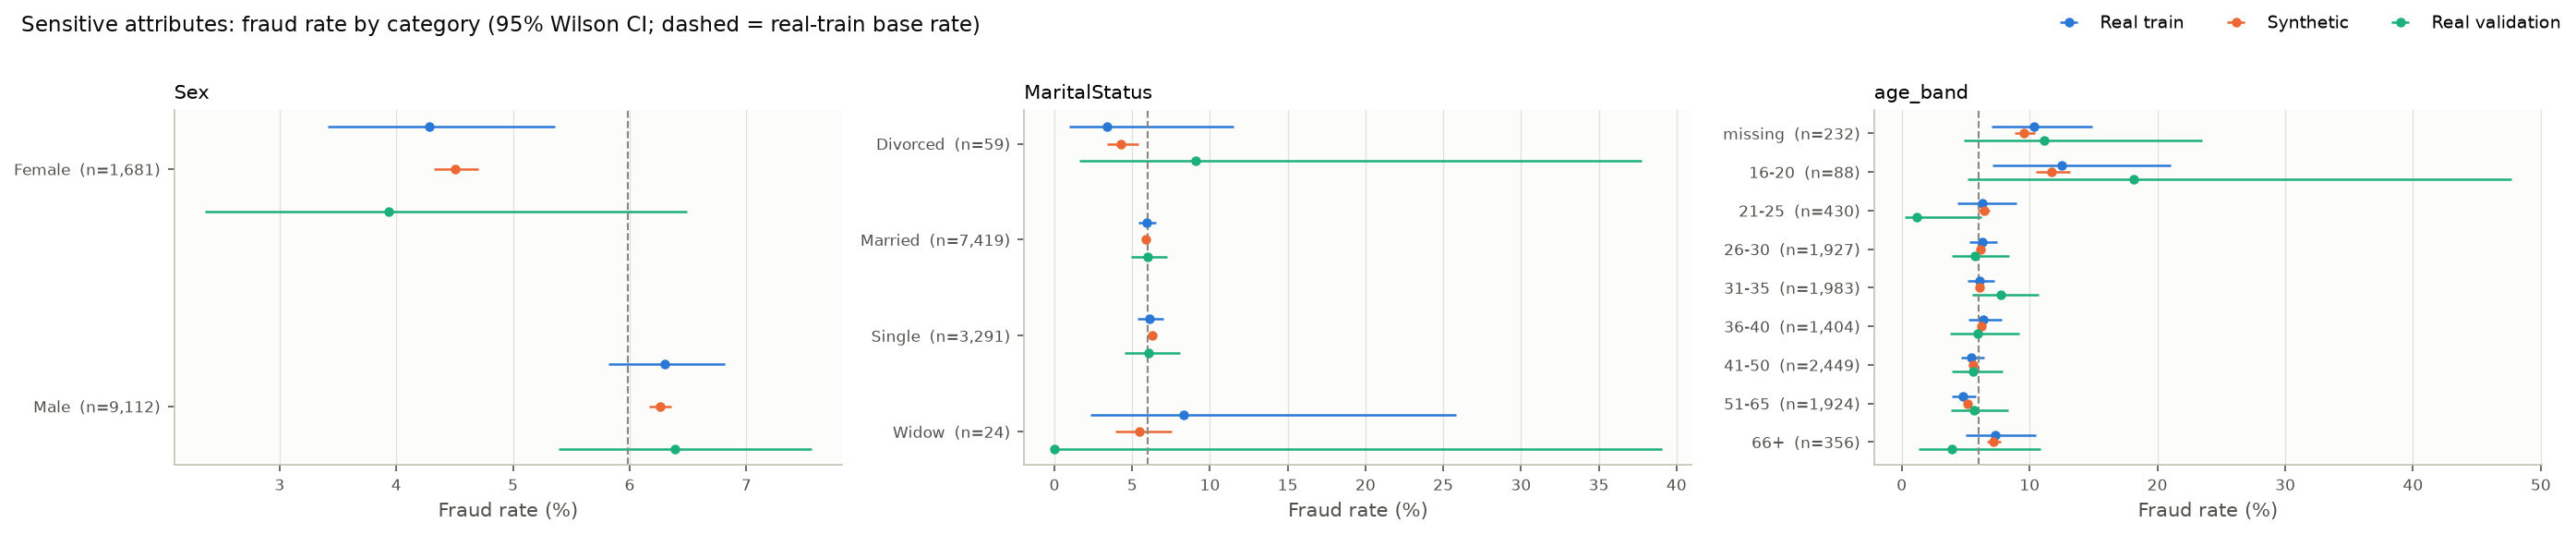

,config,pr_auc,pr_lo,pr_hi,roc_auc,delta_vs_all,delta_lo,delta_hi
0,all features,0.2662,0.2182,0.3413,0.8678,0.0000,0.0000,0.0000
1,without Sex,0.2706,0.2205,0.3407,0.8671,0.0044,-0.0154,0.0243
2,without MaritalStatus,0.2642,0.2184,0.3383,0.8663,-0.0020,-0.0153,0.0094
3,without Sex and MaritalStatus,0.2624,0.2141,0.3330,0.8643,-0.0038,-0.0244,0.0154
4,"without Sex, MaritalStatus and Age",0.2741,0.2288,0.3457,0.8725,0.0079,-0.0191,0.0374


In [18]:
if RUN_SECTIONS["fraud_eda"]:
    sens = pd.concat([eda.rates_by_origin({"real_train": rt, "synthetic": syn, "real_validation": va}, c)
                      for c in eda.SENSITIVE], ignore_index=True)
    sens.to_csv(TAB / "01_eda_sensitive_rates.csv", index=False)
    p = eda.plot_rate_grid({"real_train": rt, "synthetic": syn, "real_validation": va}, eda.SENSITIVE, BASE,
                           "Sensitive attributes", FIG / "01_rates_sensitive.png", ncols=3)
    display(Image(p))

    base_feats = sa.AUDIT_FEATURES
    ablation_sets = {
        "all features": base_feats,
        "without Sex": [f for f in base_feats if f != "Sex"],
        "without MaritalStatus": [f for f in base_feats if f != "MaritalStatus"],
        "without Sex and MaritalStatus": [f for f in base_feats if f not in ("Sex", "MaritalStatus")],
        "without Sex, MaritalStatus and Age": [f for f in base_feats if f not in ("Sex", "MaritalStatus", "Age")],
    }
    abl_rows, abl_scores = [], {}
    for name, feats in ablation_sets.items():
        res = sa.utility_experiment(raw["real_train"], raw["synthetic"], raw["real_validation"],
                                    {name: dict(real=True, syn_frac=1.0, syn_weight=0.3)},
                                    features=feats, seeds=SEEDS, n_boot=N_BOOT)
        abl_rows.append(res["table"]); abl_scores[name] = res["scores"][name]
    abl = pd.concat(abl_rows, ignore_index=True)
    from sklearn.metrics import average_precision_score
    from src.ml.evaluate import paired_bootstrap_diff
    y_val = raw["real_validation"][TARGET].to_numpy()
    for name in ablation_sets:
        d = paired_bootstrap_diff(y_val, abl_scores[name], abl_scores["all features"], average_precision_score, n_boot=N_BOOT)
        abl.loc[abl.config == name, ["delta_vs_all", "delta_lo", "delta_hi"]] = d
    abl.to_csv(TAB / "01_eda_sensitive_ablation.csv", index=False)
    display(abl[["config", "pr_auc", "pr_lo", "pr_hi", "roc_auc", "delta_vs_all", "delta_lo", "delta_hi"]].round(4))

## 4. Red-flag rules

These rules were curated from conditions mined on real train: single and pairwise
`column = value` conditions with n ≥ 40, lift ≥ 1.6, and a Wilson lower bound above the base
rate. Each one is then checked on synthetic data and on real validation. Statistics are written
into `config/policy_rules.yaml`.

513 candidate conditions; top 15:


,condition,order,n,fraud,rate,lo,hi,lift
0,Fault=Third Party & Deductible=500,2,55,30,0.545,0.415,0.670,9.113
1,Fault=Third Party & AddressChange_Claim=2 to 3...,2,56,30,0.536,0.407,0.660,8.950
2,VehicleCategory=Sedan & Deductible=500,2,105,39,0.371,0.285,0.467,6.206
3,Deductible=500 & BasePolicy=All Perils,2,52,20,0.385,0.265,0.520,6.426
4,VehicleCategory=Sedan & AddressChange_Claim=2 ...,2,116,40,0.345,0.265,0.435,5.761
5,PastNumberOfClaims=none & AddressChange_Claim=...,2,59,22,0.373,0.261,0.500,6.230
6,AddressChange_Claim=2 to 3 years & BasePolicy=...,2,57,21,0.368,0.255,0.498,6.155
7,Deductible=500 & PastNumberOfClaims=none,2,52,19,0.365,0.248,0.501,6.105
8,Deductible=500 & BasePolicy=Collision,2,61,21,0.344,0.237,0.470,5.752
9,AddressChange_Claim=2 to 3 years & BasePolicy=...,2,68,22,0.324,0.224,0.442,5.405


n                                 rate                                 lift                          
origin                          real_train real_validation synthetic real_train real_validation synthetic real_train real_validation synthetic
id                                                                                                                                            
RF01_PH_FAULT_ALL_PERILS            1944.0           445.0   52032.0      0.157           0.148     0.157      2.630           2.468     2.625
RF02_PH_FAULT_COLLISION             2906.0           625.0   77652.0      0.098           0.102     0.097      1.633           1.704     1.616
RF03_DEDUCTIBLE_500                  187.0            28.0    4860.0      0.225           0.071     0.185      3.752           1.189     3.094
RF04_THIRD_PARTY_DEDUCTIBLE_500       55.0             7.0    1273.0      0.545           0.286     0.445      9.113           4.754     7.428
RF05_ADDRESS_CHANGE_2_3Y             207.0            33.0    5242.0      0.213           0.121     0.178      3.551           2.017     2.967
RF07_EARLY_POLICY_INCIDENT            37.0            20.0     899.0      0.189           0.100     0.095      3.161           1.664     1.580
RF08_MISSING_AGE_ALL_PERILS           83.0            13.0    1701.0      0.229           0.308     0.235      3.825           5.120     3.919
RF09_YOUNG_HOLDER_AT_FAULT            61.0             7.0    1427.0      0.180           0.286     0.170      3.013           4.754     2.845
RF10_SPORT_COLLISION                 246.0            46.0    6533.0      0.110           0.239     0.107      1.834           3.979     1.788
RF11_SEDAN_PRICE_EXTREME            1340.0           284.0   35507.0      0.101           0.102     0.096      1.683           1.699     1.601
RF12_UTILITY_ALL_PERILS              243.0            60.0    6422.0      0.119           0.150     0.118      1.994           2.496     1.964
RF13_MAKE_ACCURA                     325.0            76.0    8694.0      0.123           0.105     0.073      2.056           1.752     1.226

Rules-only score on real validation: PR-AUC 0.142, ROC-AUC 0.781; claims with >=1 warning flag: 21.1%


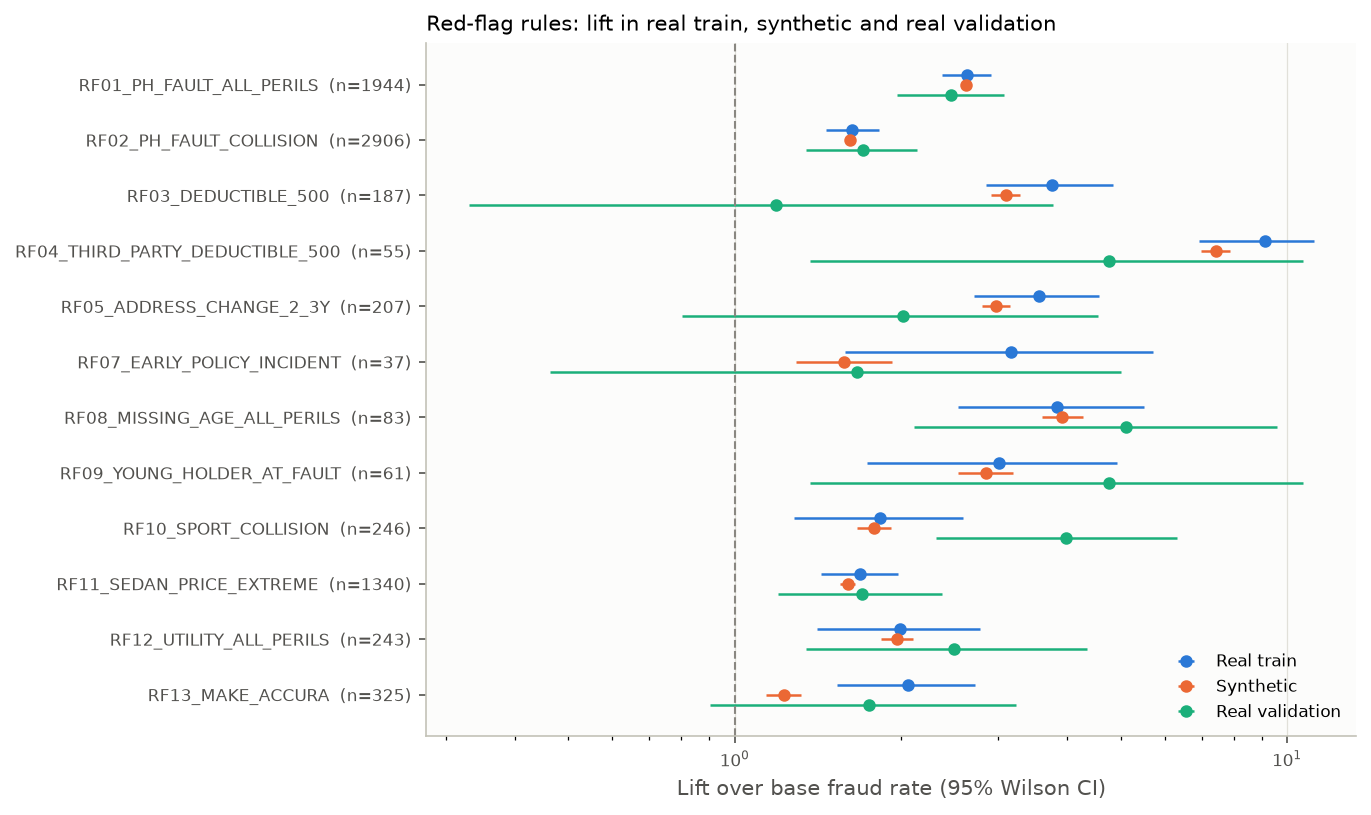

In [19]:
if RUN_SECTIONS["red_flags"]:
    mine_cols = [c for c in CLAIM_FIELDS if c not in ("Age", "PolicyType", "AgeOfPolicyHolder", "RepNumber")] + ["age_band", "claim_lag_bucket"]
    mined = eda.mine_conditions(rt, mine_cols, min_support=40, min_lift=1.6)
    mined.to_csv(TAB / "01_eda_mined_conditions.csv", index=False)
    print(f"{len(mined)} candidate conditions; top 15:"); display(mined.head(15).round(3))

    flags = load_red_flags()
    rf_stats = eda.red_flag_stats({"real_train": raw["real_train"], "synthetic": raw["synthetic"],
                                   "real_validation": raw["real_validation"]},
                                  [{"id": f.rule_id, "when": f.when} for f in flags])
    rf_stats.to_csv(TAB / "01_eda_red_flags.csv", index=False)
    if not FAST_MODE:   # only full-data statistics go into the policy file
        eda.write_red_flag_stats(rf_stats)
    display(rf_stats.pivot(index="id", columns="origin", values=["n", "rate", "lift"]).round(3))

    # Fired-flag count as a single score, checked on real validation
    y_val = raw["real_validation"][TARGET].to_numpy()
    fired = red_flag_frame(raw["real_validation"], flags)
    weights = {f.rule_id: 2 if f.severity == "warning" else 1 for f in flags}
    flag_score = (fired * pd.Series(weights)).sum(axis=1)
    from sklearn.metrics import average_precision_score, roc_auc_score
    print(f"Rules-only score on real validation: PR-AUC {average_precision_score(y_val, flag_score):.3f}, "
          f"ROC-AUC {roc_auc_score(y_val, flag_score):.3f}; claims with >=1 warning flag: "
          f"{(fired[[f.rule_id for f in flags if f.severity == 'warning']].any(axis=1)).mean():.1%}")

    order = [f.rule_id for f in flags]
    fig, ax = plt.subplots(figsize=(8, 6))
    series = {}
    for origin in ["real_train", "synthetic", "real_validation"]:
        t = rf_stats[rf_stats.origin == origin].set_index("id").reindex(order)
        b = {"real_train": BASE, "synthetic": syn[TARGET].mean(), "real_validation": va[TARGET].mean()}[origin]
        series[eda.ORIGIN_LABELS[origin]] = (t.lift, t.lo / b, t.hi / b)
    eda.plot_dots(ax, [f"{o}  (n={int(n)})" for o, n in zip(order, rf_stats[rf_stats.origin == "real_train"].set_index("id").reindex(order).n)],
                  series, "Lift over base fraud rate (95% Wilson CI)", ref=1.0,
                  colors={eda.ORIGIN_LABELS[k]: v for k, v in eda.ORIGIN_COLORS.items()})
    ax.set_xscale("log")
    ax.set_title("Red-flag rules: lift in real train, synthetic and real validation", loc="left", fontsize=10)
    eda.save(fig, FIG / "01_red_flags.png"); display(Image(FIG / "01_red_flags.png"))

In [20]:
print(f"Notebook finished in {time.time() - t0:.0f} s")

Notebook finished in 994 s
